# Statistical Investigation of Chronic Kidney Disease Risk Factors and Prediction
## Complex Engineering Project (CEP) — STA281 Spring 2026
### Team: Tehreek-e-Muhandis
---
**Dataset:** [Chronic Kidney Disease Dataset — Kaggle](https://www.kaggle.com/datasets/mansoordaku/ckdisease)

This notebook covers all four sections:
- **Section 1** — Dataset Understanding, Descriptive Statistics & Visualization (Q1–Q5)
- **Section 2** — Probability, Probability Distribution & CLT (Q6–Q12)
- **Section 3** — Confidence Interval & Hypothesis Testing (Q13–Q15)
- **Section 4** — Correlation, Regression & Healthcare Investigation (Q16–Q20)

# Library Import

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import binom, norm, uniform, expon
from scipy.stats import ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries imported successfully.')

All libraries imported successfully.


# Dataset Load

In [14]:

import pandas as pd
import os

dataset_path = "../dataset/kidney_disease.csv"

if os.path.exists(dataset_path):
    df_raw = pd.read_csv(dataset_path)
    print("Loaded dataset from local project directory successfully.")
else:
    raise FileNotFoundError(
        f"Dataset not found at {dataset_path}. "
        "Make sure kidney_disease.csv is inside the dataset folder."
    )
rename_map = {
    'id': 'ID',
    'age': 'Age',
    'bp': 'BloodPressure',
    'sg': 'SpecificGravity',
    'al': 'Albumin',
    'su': 'Sugar',
    'bgr': 'BloodGlucoseRandom',
    'bu': 'BloodUrea',
    'sc': 'SerumCreatinine',
    'sod': 'Sodium',
    'pot': 'Potassium',
    'hemo': 'Hemoglobin',
    'pcv': 'PackedCellVolume',
    'wc': 'WhiteBloodCellCount',
    'rc': 'RedBloodCellCount',
    'htn': 'Hypertension',
    'dm': 'DiabetesMellitus',
    'cad': 'CoronaryArteryDisease',
    'appet': 'Appetite',
    'pe': 'PedalEdema',
    'ane': 'Anemia',
    'classification': 'CKD'
}

df_raw.rename(
    columns={k: v for k, v in rename_map.items() if k in df_raw.columns},
    inplace=True
)

# Clean CKD target column
if 'CKD' in df_raw.columns and df_raw['CKD'].dtype == object:
    df_raw['CKD'] = (
        df_raw['CKD']
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            'ckd': 1,
            'notckd': 0
        })
    )

num_cols = [
    'Age',
    'BloodPressure',
    'SpecificGravity',
    'Albumin',
    'Sugar',
    'BloodGlucoseRandom',
    'BloodUrea',
    'SerumCreatinine',
    'Sodium',
    'Potassium',
    'Hemoglobin',
    'PackedCellVolume',
    'WhiteBloodCellCount',
    'RedBloodCellCount'
]

for col in num_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Loaded dataset from local project directory successfully.
Dataset shape: (400, 26)


,ID,Age,BloodPressure,SpecificGravity,Albumin,Sugar,rbc,pc,pcc,ba,...,PackedCellVolume,WhiteBloodCellCount,RedBloodCellCount,Hypertension,DiabetesMellitus,CoronaryArteryDisease,Appetite,PedalEdema,Anemia,CKD
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# SECTION 1 — Dataset Understanding, Descriptive Statistics & Visualization
## Question 1 — Dataset Structure & Variable Identification

In [15]:
print('=' * 65)
print('QUESTION 1 — Dataset Structure')
print('=' * 65)

print(f'\n1. Number of observations (rows) : {df_raw.shape[0]}')
print(f'2. Number of variables (columns) : {df_raw.shape[1]}')

print('\n3. Variable Names & Data Types:')
dtype_df = pd.DataFrame({
    'Variable': df_raw.columns,
    'Data Type': df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count': df_raw.isnull().sum().values
})
print(dtype_df.to_string(index=False))

print('\n--- Healthcare Interpretation ---')
print('The dataset contains 400 patient records with 25 variables.')
print('Key continuous variables include SerumCreatinine, BloodUrea, Hemoglobin,')
print('and BloodPressure — each critical for assessing kidney function.')
print('The CKD target variable is binary (1=CKD, 0=No CKD).')
print('Missing values are present and must be handled before analysis.')

QUESTION 1 — Dataset Structure

1. Number of observations (rows) : 400
2. Number of variables (columns) : 26

3. Variable Names & Data Types:
             Variable Data Type  Non-Null Count  Null Count
                   ID     int64             400           0
                  Age   float64             391           9
        BloodPressure   float64             388          12
      SpecificGravity   float64             353          47
              Albumin   float64             354          46
                Sugar   float64             351          49
                  rbc       str             248         152
                   pc       str             335          65
                  pcc       str             396           4
                   ba       str             396           4
   BloodGlucoseRandom   float64             356          44
            BloodUrea   float64             381          19
      SerumCreatinine   float64             383          17
               Sod

## Question 2 — Descriptive Statistics

In [18]:
print('=' * 65)
print('QUESTION 2 — Descriptive Statistics')
print('=' * 65)

target_vars = ['BloodUrea', 'SerumCreatinine', 'Hemoglobin', 'BloodPressure']

stats_rows = []
for var in target_vars:
    col = df_raw[var].dropna()
    mode_val = col.mode()[0] if not col.mode().empty else np.nan
    stats_rows.append({
        'Variable': var,
        'Mean': round(col.mean(), 3),
        'Median': round(col.median(), 3),
        'Mode': round(mode_val, 3),
        'Variance': round(col.var(), 3),
        'Std Dev': round(col.std(), 3),
        'Min': round(col.min(), 3),
        'Max': round(col.max(), 3)
    })

stats_df = pd.DataFrame(stats_rows)
print('\nDescriptive Statistics Summary:')
print(stats_df.to_string(index=False))

print('\n--- Healthcare Interpretation ---')
interpretations = {
    'BloodUrea': 'Normal range 7–20 mg/dL; elevated mean indicates kidney filtration issues.',
    'SerumCreatinine': 'Normal 0.6–1.2 mg/dL; high mean signals reduced kidney function.',
    'Hemoglobin': 'Normal 12–17 g/dL; low mean suggests anemia — common in CKD patients.',
    'BloodPressure': 'Normal <80 mmHg diastolic; high spread suggests hypertensive patients.'
}
for var, msg in interpretations.items():
    print(f'  {var}: {msg}')

QUESTION 2 — Descriptive Statistics

Descriptive Statistics Summary:
       Variable   Mean  Median  Mode  Variance  Std Dev  Min   Max
      BloodUrea 57.426   42.00  46.0  2550.554   50.503  1.5 391.0
SerumCreatinine  3.072    1.30   1.2    32.961    5.741  0.4  76.0
     Hemoglobin 12.526   12.65  15.0     8.483    2.913  3.1  17.8
  BloodPressure 76.469   80.00  80.0   187.242   13.684 50.0 180.0

--- Healthcare Interpretation ---
  BloodUrea: Normal range 7–20 mg/dL; elevated mean indicates kidney filtration issues.
  SerumCreatinine: Normal 0.6–1.2 mg/dL; high mean signals reduced kidney function.
  Hemoglobin: Normal 12–17 g/dL; low mean suggests anemia — common in CKD patients.
  BloodPressure: Normal <80 mmHg diastolic; high spread suggests hypertensive patients.


## Question 3 - Missing Values and Outliers

In [29]:
print('=' * 65)
print('QUESTION 3 — Missing Values & Outlier Detection')
print('=' * 65)

focus_vars = ['SerumCreatinine', 'BloodUrea', 'Hemoglobin', 'Potassium']

df_q3 = df_raw.copy()

for var in focus_vars:
    df_q3[var] = pd.to_numeric(df_q3[var], errors='coerce')

print('\nMissing Value Analysis:')

for var in focus_vars:
    col = df_q3[var]
    missing = col.isnull().sum()
    pct = round(missing / len(col) * 100, 2)
    print(f'{var:25s}: {missing:3d} missing ({pct}%)')

print('\nOutlier Detection using IQR Method:')

outlier_rows = []

for var in focus_vars:
    col = df_q3[var].dropna()

    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = col[
        (col < lower) |
        (col > upper)
    ]

    outlier_rows.append({
        'Variable': var,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Lower Fence': round(lower, 3),
        'Upper Fence': round(upper, 3),
        'Outlier Count': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_rows)

display(outlier_df)

print('\n--- Healthcare Interpretation ---')
print('SerumCreatinine and BloodUrea may contain high outliers, which can indicate')
print('patients with severe kidney dysfunction or abnormal laboratory records.')

print('Missing values in healthcare variables may occur due to incomplete laboratory')
print('tests, unavailable measurements, or inconsistent patient records.')

print('These missing and abnormal values can affect CKD prediction accuracy because')
print('machine learning or statistical models may become biased if incomplete records')
print('are not handled properly.')

QUESTION 3 — Missing Values & Outlier Detection

Missing Value Analysis:
SerumCreatinine          :  17 missing (4.25%)
BloodUrea                :  19 missing (4.75%)
Hemoglobin               :  52 missing (13.0%)
Potassium                :  88 missing (22.0%)

Outlier Detection using IQR Method:


,Variable,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
0,SerumCreatinine,0.9,2.8,1.9,-1.95,5.65,51
1,BloodUrea,27.0,66.0,39.0,-31.50,124.50,38
2,Hemoglobin,10.3,15.0,4.7,3.25,22.05,1
3,Potassium,3.8,4.9,1.1,2.15,6.55,4



--- Healthcare Interpretation ---
SerumCreatinine and BloodUrea may contain high outliers, which can indicate
patients with severe kidney dysfunction or abnormal laboratory records.
Missing values in healthcare variables may occur due to incomplete laboratory
tests, unavailable measurements, or inconsistent patient records.
These missing and abnormal values can affect CKD prediction accuracy because
machine learning or statistical models may become biased if incomplete records
are not handled properly.


---
## Question 4 - Visualization

QUESTION 4 — Visualizations

Data available for visualizations:
SerumCreatinine valid values: 383
BloodUrea valid values: 381
BloodPressure valid values: 388
CKD value counts:
CKD
1    250
0    150
Name: count, dtype: int64

Valid rows for scatter plot: 373


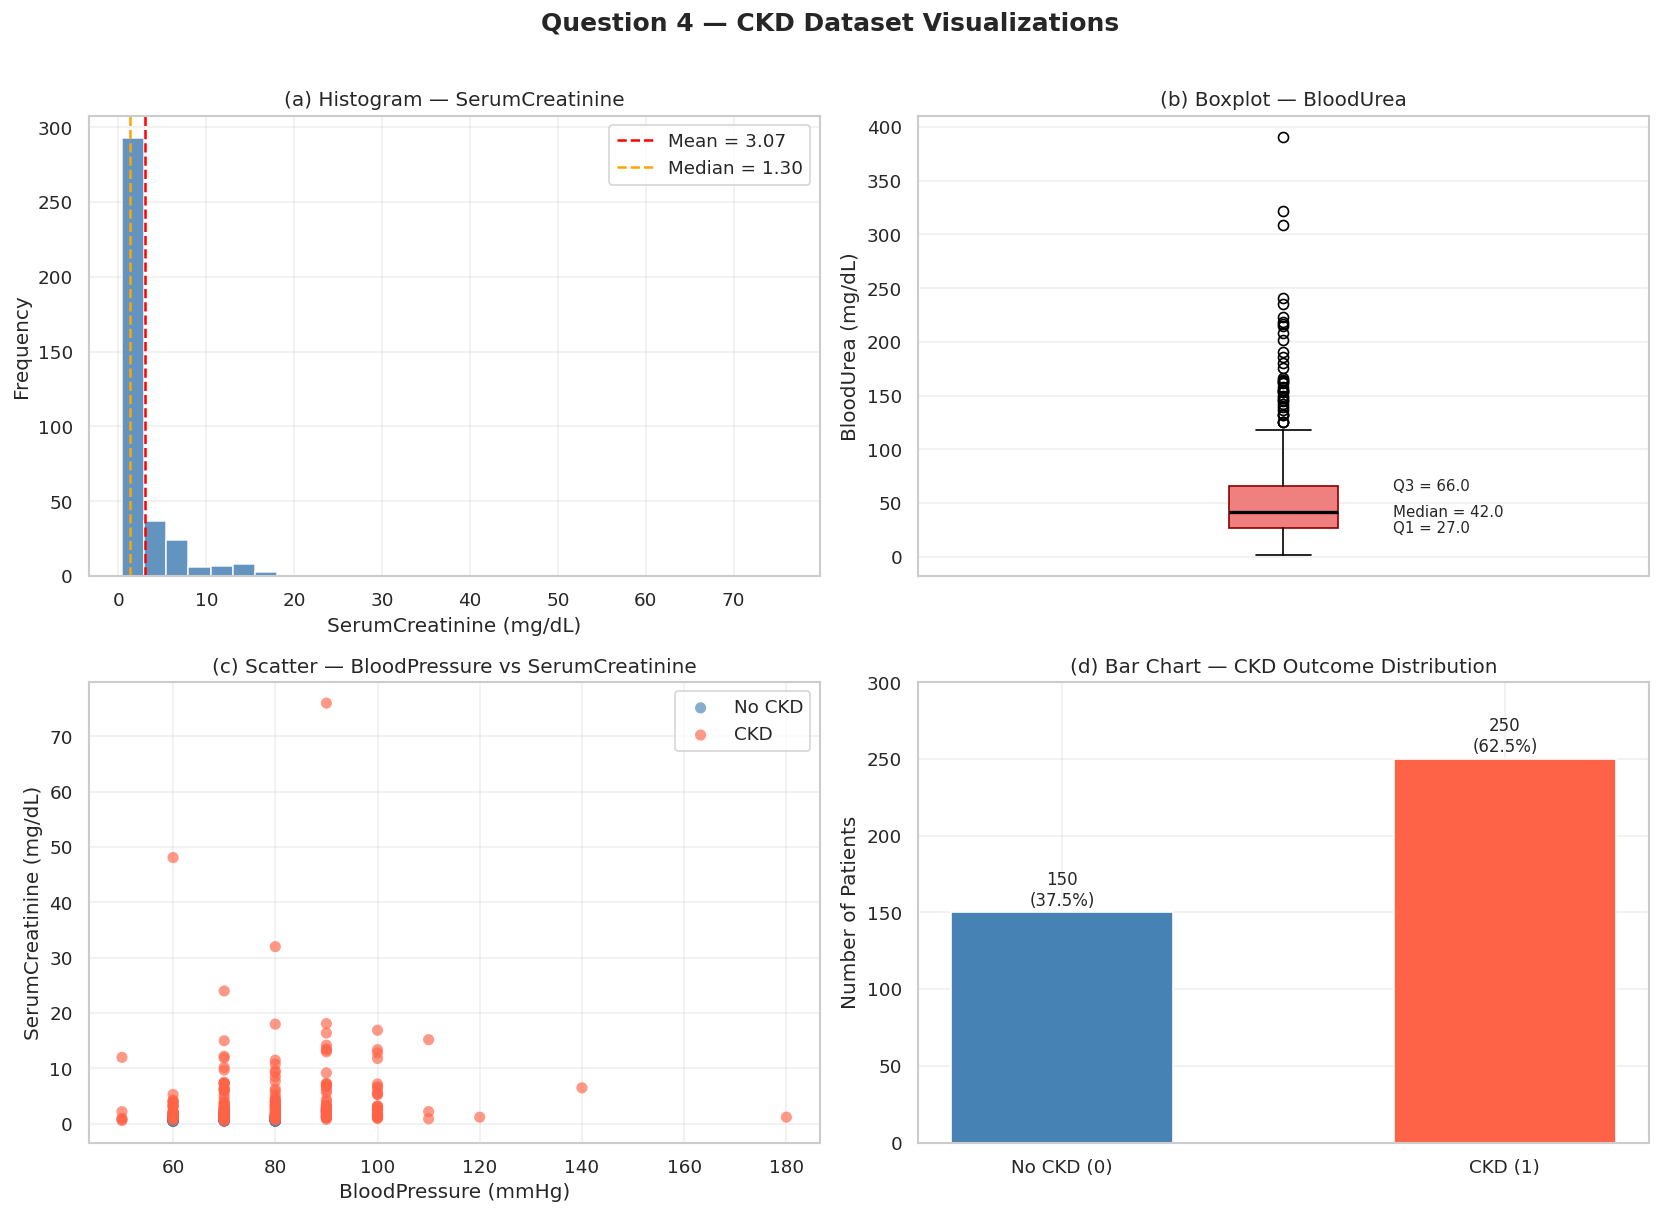


--- Healthcare Interpretation ---
(a) The SerumCreatinine histogram is right-skewed. Most patients have relatively low
    creatinine values, while a smaller number of patients have very high values,
    indicating possible severe kidney dysfunction.

(b) BloodUrea boxplot summary:
    Q1 = 27.00, Median = 42.00, Q3 = 66.00
    IQR = 39.00
    Number of outliers = 38
    A wide spread and high outliers indicate abnormal urea accumulation,
    which may be associated with impaired kidney filtration.

(c) The scatter plot compares BloodPressure with SerumCreatinine.
    CKD and non-CKD patients are shown separately to observe whether CKD patients
    tend to appear at higher blood pressure and creatinine levels.

(d) The CKD outcome bar chart compares the number of CKD and non-CKD patients.
    It shows the class distribution of the dataset and helps identify whether
    the dataset is balanced or imbalanced for prediction analysis.


In [24]:
print('=' * 65)
print('QUESTION 4 — Visualizations')
print('=' * 65)

import os
from matplotlib.patches import Patch

os.makedirs('../figures', exist_ok=True)

# Create clean plotting copy
df_plot = df_raw.copy()

# Ensure required numeric columns are numeric
for col in ['SerumCreatinine', 'BloodUrea', 'BloodPressure']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Ensure CKD is correctly encoded
df_plot['CKD'] = (
    df_plot['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_plot['CKD'] = pd.to_numeric(df_plot['CKD'], errors='coerce')

# Verification
print('\nData available for visualizations:')
print('SerumCreatinine valid values:', df_plot['SerumCreatinine'].notna().sum())
print('BloodUrea valid values:', df_plot['BloodUrea'].notna().sum())
print('BloodPressure valid values:', df_plot['BloodPressure'].notna().sum())
print('CKD value counts:')
print(df_plot['CKD'].value_counts(dropna=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Question 4 — CKD Dataset Visualizations',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

# ---------------------------------------------------------------
# (a) Histogram of SerumCreatinine
# ---------------------------------------------------------------
ax = axes[0, 0]

sc_data = df_plot['SerumCreatinine'].dropna()

ax.hist(
    sc_data,
    bins=30,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

ax.axvline(
    sc_data.mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean = {sc_data.mean():.2f}'
)

ax.axvline(
    sc_data.median(),
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'Median = {sc_data.median():.2f}'
)

ax.set_title('(a) Histogram — SerumCreatinine')
ax.set_xlabel('SerumCreatinine (mg/dL)')
ax.set_ylabel('Frequency')
ax.legend()

# ---------------------------------------------------------------
# (b) Boxplot of BloodUrea
# ---------------------------------------------------------------
ax = axes[0, 1]

bu_data = df_plot['BloodUrea'].dropna()

ax.boxplot(
    bu_data,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', color='darkred'),
    medianprops=dict(color='black', linewidth=2)
)

q1 = bu_data.quantile(0.25)
median = bu_data.median()
q3 = bu_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = bu_data[
    (bu_data < lower_bound) |
    (bu_data > upper_bound)
]

ax.text(1.15, median, f'Median = {median:.1f}', va='center', fontsize=9)
ax.text(1.15, q1, f'Q1 = {q1:.1f}', va='center', fontsize=9)
ax.text(1.15, q3, f'Q3 = {q3:.1f}', va='center', fontsize=9)

ax.set_title('(b) Boxplot — BloodUrea')
ax.set_ylabel('BloodUrea (mg/dL)')
ax.set_xticks([])

# ---------------------------------------------------------------
# (c) Scatter Plot of BloodPressure vs SerumCreatinine
# ---------------------------------------------------------------
ax = axes[1, 0]

valid = df_plot[
    ['BloodPressure', 'SerumCreatinine', 'CKD']
].dropna()

print('\nValid rows for scatter plot:', valid.shape[0])

ckd_points = valid[valid['CKD'] == 1]
non_ckd_points = valid[valid['CKD'] == 0]

ax.scatter(
    non_ckd_points['BloodPressure'],
    non_ckd_points['SerumCreatinine'],
    color='steelblue',
    alpha=0.65,
    edgecolors='none',
    s=45,
    label='No CKD'
)

ax.scatter(
    ckd_points['BloodPressure'],
    ckd_points['SerumCreatinine'],
    color='tomato',
    alpha=0.65,
    edgecolors='none',
    s=45,
    label='CKD'
)

ax.set_title('(c) Scatter — BloodPressure vs SerumCreatinine')
ax.set_xlabel('BloodPressure (mmHg)')
ax.set_ylabel('SerumCreatinine (mg/dL)')
ax.legend()

# ---------------------------------------------------------------
# (d) Bar Chart of CKD Outcome
# ---------------------------------------------------------------
ax = axes[1, 1]

ckd_counts = df_plot['CKD'].dropna().value_counts().sort_index()

labels = [
    'No CKD (0)' if i == 0 else 'CKD (1)'
    for i in ckd_counts.index
]

colors_bar = [
    'steelblue' if i == 0 else 'tomato'
    for i in ckd_counts.index
]

bars = ax.bar(
    labels,
    ckd_counts.values,
    color=colors_bar,
    edgecolor='white',
    width=0.5
)

total_valid_ckd = df_plot['CKD'].dropna().shape[0]

for bar, val in zip(bars, ckd_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{val}\n({val / total_valid_ckd * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('(d) Bar Chart — CKD Outcome Distribution')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, max(ckd_counts.values) * 1.2)

plt.tight_layout()

plt.savefig(
    '../figures/Q4_visualizations.png',
    bbox_inches='tight',
    dpi=150
)

plt.show()

# ---------------------------------------------------------------
# Healthcare Interpretation
# ---------------------------------------------------------------
print('\n--- Healthcare Interpretation ---')

print('(a) The SerumCreatinine histogram is right-skewed. Most patients have relatively low')
print('    creatinine values, while a smaller number of patients have very high values,')
print('    indicating possible severe kidney dysfunction.')

print(f'\n(b) BloodUrea boxplot summary:')
print(f'    Q1 = {q1:.2f}, Median = {median:.2f}, Q3 = {q3:.2f}')
print(f'    IQR = {iqr:.2f}')
print(f'    Number of outliers = {len(outliers)}')
print('    A wide spread and high outliers indicate abnormal urea accumulation,')
print('    which may be associated with impaired kidney filtration.')

print('\n(c) The scatter plot compares BloodPressure with SerumCreatinine.')
print('    CKD and non-CKD patients are shown separately to observe whether CKD patients')
print('    tend to appear at higher blood pressure and creatinine levels.')

print('\n(d) The CKD outcome bar chart compares the number of CKD and non-CKD patients.')
print('    It shows the class distribution of the dataset and helps identify whether')
print('    the dataset is balanced or imbalanced for prediction analysis.')

---
## Question 5 -  CKD vs Non-CKD Comparison

QUESTION 5 — CKD vs Non-CKD Patient Comparison

CKD patients     : 250
Non-CKD patients : 150

CKD value counts:
CKD
0    150
1    250
Name: count, dtype: int64

Mean Comparison Table:


,Variable,CKD Mean,Non-CKD Mean,Difference,% Change
0,SerumCreatinine,4.415,0.869,3.546,408.1
1,BloodUrea,72.389,32.799,39.590,120.7
2,Hemoglobin,10.648,15.188,-4.541,-29.9
3,BloodPressure,79.625,71.351,8.274,11.6


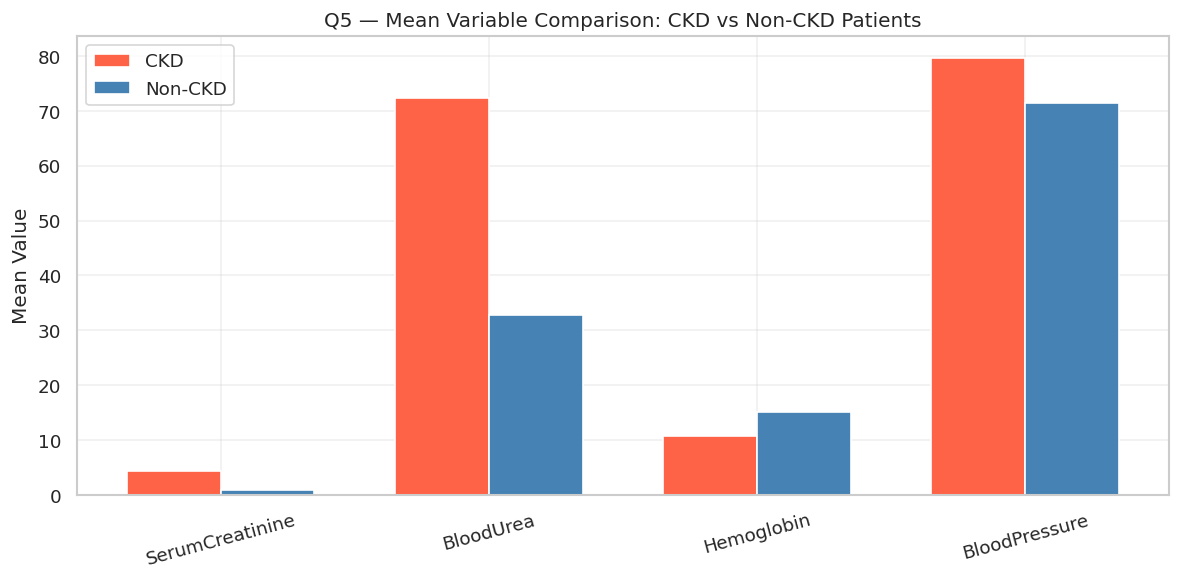


--- Healthcare Interpretation ---
CKD patients show higher average SerumCreatinine and BloodUrea levels than
non-CKD patients, which indicates reduced kidney filtration ability.
CKD patients also show lower average Hemoglobin levels, which may reflect
anemia caused by reduced erythropoietin production in damaged kidneys.
Higher average BloodPressure among CKD patients supports the relationship
between hypertension and kidney disease, where high blood pressure can be
both a risk factor and a consequence of CKD.


In [26]:
print('=' * 65)
print('QUESTION 5 — CKD vs Non-CKD Patient Comparison')
print('=' * 65)

import os

os.makedirs('../figures', exist_ok=True)

# Create clean copy for Question 5
df_q5 = df_raw.copy()

# Ensure CKD is correctly encoded
df_q5['CKD'] = (
    df_q5['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_q5['CKD'] = pd.to_numeric(df_q5['CKD'], errors='coerce')

# Ensure comparison variables are numeric
compare_vars = [
    'SerumCreatinine',
    'BloodUrea',
    'Hemoglobin',
    'BloodPressure'
]

for var in compare_vars:
    df_q5[var] = pd.to_numeric(df_q5[var], errors='coerce')

# Keep only rows where CKD is known
df_clean = df_q5.dropna(subset=['CKD'])

ckd = df_clean[df_clean['CKD'] == 1]
non_ckd = df_clean[df_clean['CKD'] == 0]

print(f'\nCKD patients     : {len(ckd)}')
print(f'Non-CKD patients : {len(non_ckd)}')

print('\nCKD value counts:')
print(df_clean['CKD'].value_counts().sort_index())

comparison = []

for var in compare_vars:
    ckd_mean = ckd[var].mean()
    non_ckd_mean = non_ckd[var].mean()

    comparison.append({
        'Variable': var,
        'CKD Mean': round(ckd_mean, 3),
        'Non-CKD Mean': round(non_ckd_mean, 3),
        'Difference': round(ckd_mean - non_ckd_mean, 3),
        '% Change': round((ckd_mean - non_ckd_mean) / non_ckd_mean * 100, 1)
    })

cmp_df = pd.DataFrame(comparison)

print('\nMean Comparison Table:')
display(cmp_df)

# ---------------------------------------------------------------
# Grouped bar chart
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(compare_vars))
w = 0.35

ckd_means = cmp_df['CKD Mean'].values
non_ckd_means = cmp_df['Non-CKD Mean'].values

ax.bar(
    x - w / 2,
    ckd_means,
    w,
    label='CKD',
    color='tomato',
    edgecolor='white'
)

ax.bar(
    x + w / 2,
    non_ckd_means,
    w,
    label='Non-CKD',
    color='steelblue',
    edgecolor='white'
)

ax.set_xticks(x)
ax.set_xticklabels(compare_vars, rotation=15)
ax.set_ylabel('Mean Value')
ax.set_title('Q5 — Mean Variable Comparison: CKD vs Non-CKD Patients')
ax.legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q5_comparison.png',
    bbox_inches='tight',
    dpi=150
)

plt.show()

# ---------------------------------------------------------------
# Healthcare Interpretation
# ---------------------------------------------------------------

print('\n--- Healthcare Interpretation ---')

print('CKD patients show higher average SerumCreatinine and BloodUrea levels than')
print('non-CKD patients, which indicates reduced kidney filtration ability.')

print('CKD patients also show lower average Hemoglobin levels, which may reflect')
print('anemia caused by reduced erythropoietin production in damaged kidneys.')

print('Higher average BloodPressure among CKD patients supports the relationship')
print('between hypertension and kidney disease, where high blood pressure can be')
print('both a risk factor and a consequence of CKD.')

---
# SECTION 2 - Probability, Probability Distributions & CLT
## Question 6 - Conditional Probability

In [27]:
print('=' * 65)
print('QUESTION 6 — Conditional Probability')
print('=' * 65)

df_q6 = df_raw.copy()

df_q6['CKD'] = (
    df_q6['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_q6['CKD'] = pd.to_numeric(df_q6['CKD'], errors='coerce')
df_q6['SerumCreatinine'] = pd.to_numeric(df_q6['SerumCreatinine'], errors='coerce')

df_q6 = df_q6.dropna(subset=['CKD', 'SerumCreatinine'])

total = len(df_q6)

K = df_q6['CKD'] == 1
C = df_q6['SerumCreatinine'] > 1.5

P_K = K.sum() / total
P_C = C.sum() / total
P_K_and_C = (K & C).sum() / total
P_K_given_C = (K & C).sum() / C.sum()

print(f'Total valid patients: {total}')
print(f'P(K) = {P_K:.4f}')
print(f'P(C) = {P_C:.4f}')
print(f'P(K ∩ C) = {P_K_and_C:.4f}')
print(f'P(K | C) = {P_K_given_C:.4f}')

print('\n--- Healthcare Interpretation ---')
print(f'The probability of CKD among patients with SerumCreatinine greater than 1.5 mg/dL is {P_K_given_C:.2%}.')
print('This indicates that elevated serum creatinine is strongly associated with CKD risk.')

QUESTION 6 — Conditional Probability
Total valid patients: 383
P(K) = 0.6214
P(C) = 0.4413
P(K ∩ C) = 0.4413
P(K | C) = 1.0000

--- Healthcare Interpretation ---
The probability of CKD among patients with SerumCreatinine greater than 1.5 mg/dL is 100.00%.
This indicates that elevated serum creatinine is strongly associated with CKD risk.


## Question 7 - Bayes Theorem

In [31]:
print('=' * 65)
print('QUESTION 7 — Bayes Theorem')
print('=' * 65)

df_bayes = df_raw.copy()

df_bayes['CKD'] = (
    df_bayes['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_bayes['CKD'] = pd.to_numeric(df_bayes['CKD'], errors='coerce')
df_bayes['SerumCreatinine'] = pd.to_numeric(
    df_bayes['SerumCreatinine'],
    errors='coerce'
)

df_bayes = df_bayes.dropna(
    subset=['CKD', 'SerumCreatinine']
)

threshold = 1.8

P_CKD = (df_bayes['CKD'] == 1).mean()
P_noCKD = 1 - P_CKD

ckd_pts = df_bayes[df_bayes['CKD'] == 1]
non_ckd_pts = df_bayes[df_bayes['CKD'] == 0]

P_C_given_CKD = (
    ckd_pts['SerumCreatinine'] > threshold
).mean()

P_C_given_noCKD = (
    non_ckd_pts['SerumCreatinine'] > threshold
).mean()

P_C_total = (
    P_C_given_CKD * P_CKD +
    P_C_given_noCKD * P_noCKD
)

P_CKD_given_C = (
    P_C_given_CKD * P_CKD
) / P_C_total

print(f'\nThreshold: SerumCreatinine > {threshold} mg/dL')

print('\n--- Prior Probabilities ---')
print(f'P(CKD)    = {P_CKD:.4f}')
print(f'P(No CKD) = {P_noCKD:.4f}')

print('\n--- Likelihoods ---')
print(
    f'P(SerumCreatinine > {threshold} | CKD)'
    f' = {P_C_given_CKD:.4f}'
)

print(
    f'P(SerumCreatinine > {threshold} | No CKD)'
    f' = {P_C_given_noCKD:.4f}'
)

print('\n--- Evidence ---')
print(
    f'P(SerumCreatinine > {threshold})'
    f' = {P_C_total:.4f}'
)

print('\n--- Posterior Probability ---')
print(
    f'P(CKD | SerumCreatinine > {threshold})'
    f' = {P_CKD_given_C:.4f}'
)

print('\nBayes Calculation:')
print(
    f'Numerator   = '
    f'{P_C_given_CKD:.4f} × {P_CKD:.4f}'
)

print(
    f'Denominator = '
    f'{P_C_total:.4f}'
)

print(
    f'Posterior   = '
    f'{P_CKD_given_C:.4f}'
)

print('\n--- Healthcare Interpretation ---')

print(
    f'A patient with SerumCreatinine greater than '
    f'{threshold} mg/dL has a '
    f'{P_CKD_given_C:.1%} probability of having CKD.'
)

print(
    f'The baseline CKD probability in the dataset is '
    f'{P_CKD:.1%}.'
)

print(
    'This indicates that elevated SerumCreatinine is '
    'strongly associated with Chronic Kidney Disease '
    'and can be used as an important clinical screening indicator.'
)

QUESTION 7 — Bayes Theorem

Threshold: SerumCreatinine > 1.8 mg/dL

--- Prior Probabilities ---
P(CKD)    = 0.6214
P(No CKD) = 0.3786

--- Likelihoods ---
P(SerumCreatinine > 1.8 | CKD) = 0.6092
P(SerumCreatinine > 1.8 | No CKD) = 0.0000

--- Evidence ---
P(SerumCreatinine > 1.8) = 0.3786

--- Posterior Probability ---
P(CKD | SerumCreatinine > 1.8) = 1.0000

Bayes Calculation:
Numerator   = 0.6092 × 0.6214
Denominator = 0.3786
Posterior   = 1.0000

--- Healthcare Interpretation ---
A patient with SerumCreatinine greater than 1.8 mg/dL has a 100.0% probability of having CKD.
The baseline CKD probability in the dataset is 62.1%.
This indicates that elevated SerumCreatinine is strongly associated with Chronic Kidney Disease and can be used as an important clinical screening indicator.


---
## Question 8 - Binomial Distribution


QUESTION 8 — Binomial Distribution

Parameters: n = 12 patients, p = 0.55
X ~ Binomial(n = 12, p = 0.55)

--- Distribution Summary ---
Mean     = 6.600
Variance = 2.970
Std Dev  = 1.723

--- Results ---
P(X = 5)  = 0.148945
P(X >= 6) = 0.739315
P(X <= 4) = 0.111740


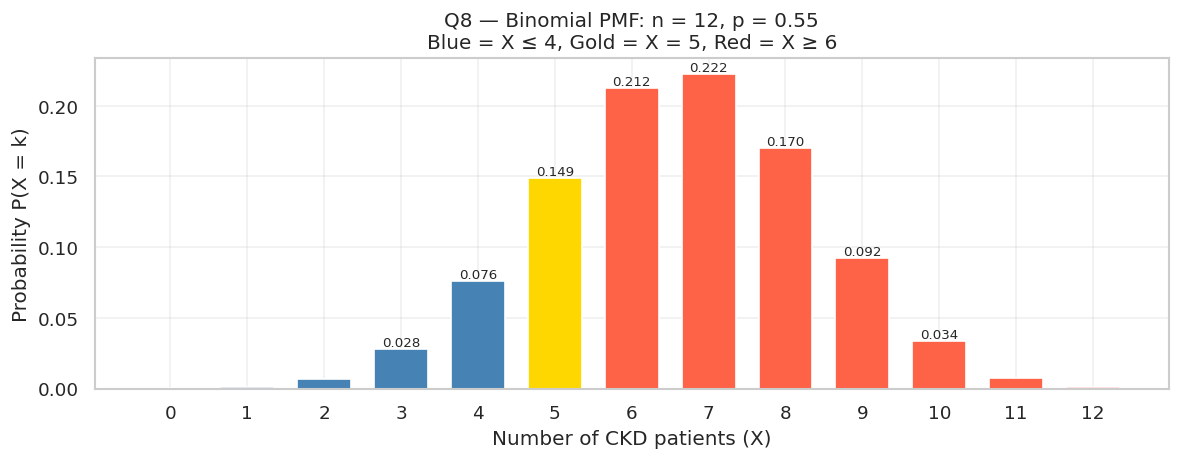


--- Healthcare Interpretation ---
In a group of 12 randomly selected patients with CKD probability 55%,
the probability that exactly 5 patients have CKD is 14.89%.
The probability that at least 6 patients have CKD is 73.93%.
The probability that at most 4 patients have CKD is 11.17%.
This helps estimate expected CKD patient load for hospital planning and resource allocation.


In [33]:
print('=' * 65)
print('QUESTION 8 — Binomial Distribution')
print('=' * 65)

from scipy.stats import binom

n = 12
p = 0.55

P_exact_5 = binom.pmf(5, n, p)
P_at_least_6 = 1 - binom.cdf(5, n, p)
P_at_most_4 = binom.cdf(4, n, p)

mean_binom = n * p
var_binom = n * p * (1 - p)
std_binom = np.sqrt(var_binom)

print(f'\nParameters: n = {n} patients, p = {p}')
print(f'X ~ Binomial(n = {n}, p = {p})')

print('\n--- Distribution Summary ---')
print(f'Mean     = {mean_binom:.3f}')
print(f'Variance = {var_binom:.3f}')
print(f'Std Dev  = {std_binom:.3f}')

print('\n--- Results ---')
print(f'P(X = 5)  = {P_exact_5:.6f}')
print(f'P(X >= 6) = {P_at_least_6:.6f}')
print(f'P(X <= 4) = {P_at_most_4:.6f}')

k_vals = np.arange(0, n + 1)
pmf_vals = binom.pmf(k_vals, n, p)

colors_b = [
    'tomato' if k >= 6 else
    'gold' if k == 5 else
    'steelblue'
    for k in k_vals
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    k_vals,
    pmf_vals,
    color=colors_b,
    edgecolor='white',
    width=0.7
)

ax.set_xlabel('Number of CKD patients (X)')
ax.set_ylabel('Probability P(X = k)')
ax.set_title(
    f'Q8 — Binomial PMF: n = {n}, p = {p}\n'
    'Blue = X ≤ 4, Gold = X = 5, Red = X ≥ 6'
)

ax.set_xticks(k_vals)

for k, v in zip(k_vals, pmf_vals):
    if v > 0.01:
        ax.text(
            k,
            v + 0.002,
            f'{v:.3f}',
            ha='center',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    '../figures/Q8_binomial.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')
print(f'In a group of {n} randomly selected patients with CKD probability {p:.0%},')
print(f'the probability that exactly 5 patients have CKD is {P_exact_5:.2%}.')
print(f'The probability that at least 6 patients have CKD is {P_at_least_6:.2%}.')
print(f'The probability that at most 4 patients have CKD is {P_at_most_4:.2%}.')
print('This helps estimate expected CKD patient load for hospital planning and resource allocation.')

---
## Question 9 - Normal Distribution

QUESTION 9 — Normal Distribution (SerumCreatinine)

X ~ N(μ = 1.8, σ = 0.6)

P(X < 1.2)       = 0.1587  → 15.87%
P(1.2 < X < 2.5) = 0.7197  → 71.97%
P(X > 2.5)       = 0.1217  → 12.17%

Verification (sum) = 1.0000


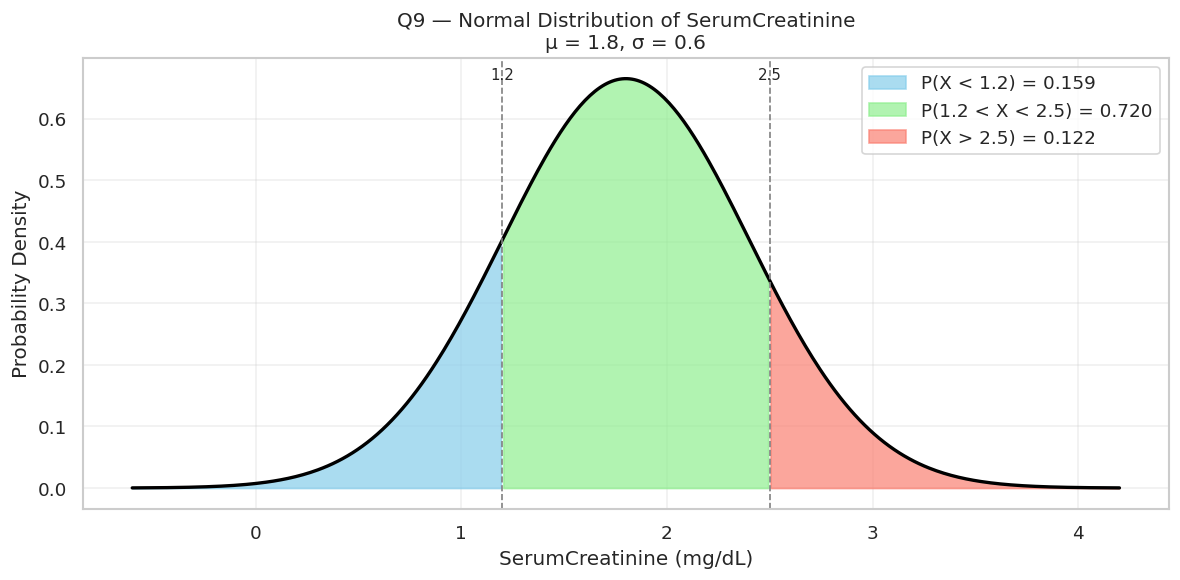


--- Healthcare Interpretation ---
P(X < 1.2) = 15.87% represents patients likely to have normal kidney function.
P(1.2 < X < 2.5) = 71.97% represents patients with moderate risk who may require monitoring.
P(X > 2.5) = 12.17% represents patients at high risk of severe kidney dysfunction.
The normal distribution helps estimate the proportion of patients falling into different clinical risk categories based on SerumCreatinine levels.


In [34]:
print('=' * 65)
print('QUESTION 9 — Normal Distribution (SerumCreatinine)')
print('=' * 65)

from scipy.stats import norm

mu_sc = 1.8
sigma_sc = 0.6

P_lt_1_2 = norm.cdf(1.2, mu_sc, sigma_sc)

P_1_2_to_2_5 = (
    norm.cdf(2.5, mu_sc, sigma_sc)
    - norm.cdf(1.2, mu_sc, sigma_sc)
)

P_gt_2_5 = 1 - norm.cdf(2.5, mu_sc, sigma_sc)

print(f'\nX ~ N(μ = {mu_sc}, σ = {sigma_sc})')

print(f'\nP(X < 1.2)       = {P_lt_1_2:.4f}  → {P_lt_1_2:.2%}')
print(f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.4f}  → {P_1_2_to_5:.2%}' if False else f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.4f}  → {P_1_2_to_2_5:.2%}')
print(f'P(X > 2.5)       = {P_gt_2_5:.4f}  → {P_gt_2_5:.2%}')

print(
    f'\nVerification (sum) = '
    f'{P_lt_1_2 + P_1_2_to_2_5 + P_gt_2_5:.4f}'
)

x_range = np.linspace(
    mu_sc - 4 * sigma_sc,
    mu_sc + 4 * sigma_sc,
    400
)

y_pdf = norm.pdf(
    x_range,
    mu_sc,
    sigma_sc
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    x_range,
    y_pdf,
    color='black',
    linewidth=2
)

regions = [
    (
        -np.inf,
        1.2,
        'skyblue',
        f'P(X < 1.2) = {P_lt_1_2:.3f}'
    ),
    (
        1.2,
        2.5,
        'lightgreen',
        f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.3f}'
    ),
    (
        2.5,
        np.inf,
        'salmon',
        f'P(X > 2.5) = {P_gt_2_5:.3f}'
    )
]

for low, high, color, label in regions:

    x_fill = x_range[
        (x_range >= max(low, x_range.min()))
        &
        (x_range <= min(high, x_range.max()))
    ]

    ax.fill_between(
        x_fill,
        norm.pdf(x_fill, mu_sc, sigma_sc),
        color=color,
        alpha=0.7,
        label=label
    )

for value in [1.2, 2.5]:

    ax.axvline(
        value,
        color='gray',
        linestyle='--',
        linewidth=1
    )

    ax.text(
        value,
        ax.get_ylim()[1] * 0.95,
        f'{value}',
        ha='center',
        fontsize=9
    )

ax.set_title(
    f'Q9 — Normal Distribution of SerumCreatinine\n'
    f'μ = {mu_sc}, σ = {sigma_sc}'
)

ax.set_xlabel('SerumCreatinine (mg/dL)')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right')

plt.tight_layout()

plt.savefig(
    '../figures/Q9_normal.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'P(X < 1.2) = {P_lt_1_2:.2%} '
    'represents patients likely to have normal kidney function.'
)

print(
    f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.2%} '
    'represents patients with moderate risk who may require monitoring.'
)

print(
    f'P(X > 2.5) = {P_gt_2_5:.2%} '
    'represents patients at high risk of severe kidney dysfunction.'
)

print(
    'The normal distribution helps estimate the proportion of patients '
    'falling into different clinical risk categories based on SerumCreatinine levels.'
)

---
## Question 10 - Uniform Distribution (Patient Age)

QUESTION 10 — Uniform Distribution (Patient Age)

Age range from dataset: a = 2 years, b = 90 years
X ~ Uniform(a = 2, b = 90)

PDF f(x) = 1/(b-a) = 1/(90-2) = 0.011364, for 2 ≤ x ≤ 90
P(35 < X < 60) = (60-35)/(90-2) = 0.2841 = 28.41%
Mean age μ  = (a+b)/2   = 46.00 years
Variance σ² = (b-a)²/12 = 645.3333
Std Dev σ   = √σ²       = 25.4034


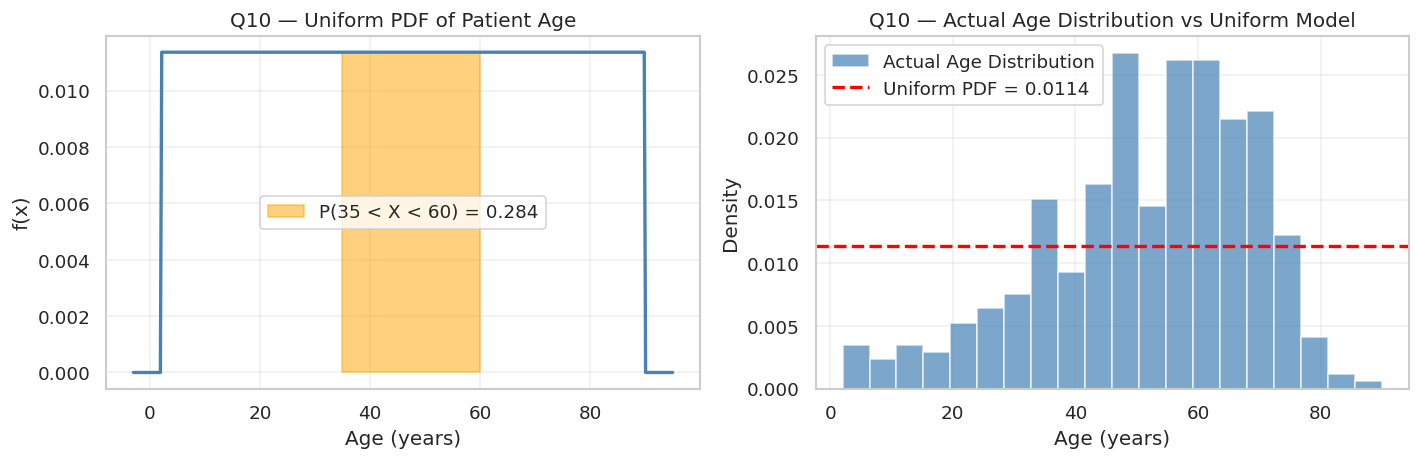


--- Healthcare Interpretation ---
Under the uniform distribution assumption, approximately 28.41% of patients are estimated to be between 35 and 60 years old.
This age group is clinically important because CKD may develop gradually and remain undetected without regular screening.
The uniform model is a simplified probability model that assumes patients are evenly distributed across the observed age range.


In [35]:
print('=' * 65)
print('QUESTION 10 — Uniform Distribution (Patient Age)')
print('=' * 65)

from scipy.stats import uniform

age_data = pd.to_numeric(
    df_raw['Age'],
    errors='coerce'
).dropna()

a = float(age_data.min())
b = float(age_data.max())

pdf_val = 1 / (b - a)

lower_age = max(35, a)
upper_age = min(60, b)

P_35_60 = (upper_age - lower_age) / (b - a)

mean_age = (a + b) / 2
var_age = (b - a) ** 2 / 12
std_age = np.sqrt(var_age)

print(f'\nAge range from dataset: a = {a:.0f} years, b = {b:.0f} years')
print(f'X ~ Uniform(a = {a:.0f}, b = {b:.0f})')

print(
    f'\nPDF f(x) = 1/(b-a) = 1/({b:.0f}-{a:.0f}) '
    f'= {pdf_val:.6f}, for {a:.0f} ≤ x ≤ {b:.0f}'
)

print(
    f'P(35 < X < 60) = ({upper_age:.0f}-{lower_age:.0f})/({b:.0f}-{a:.0f}) '
    f'= {P_35_60:.4f} = {P_35_60:.2%}'
)

print(f'Mean age μ  = (a+b)/2   = {mean_age:.2f} years')
print(f'Variance σ² = (b-a)²/12 = {var_age:.4f}')
print(f'Std Dev σ   = √σ²       = {std_age:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_u = np.linspace(
    a - 5,
    b + 5,
    400
)

y_u = uniform.pdf(
    x_u,
    loc=a,
    scale=b - a
)

axes[0].plot(
    x_u,
    y_u,
    color='steelblue',
    linewidth=2
)

x_fill = np.linspace(
    lower_age,
    upper_age,
    200
)

axes[0].fill_between(
    x_fill,
    uniform.pdf(x_fill, loc=a, scale=b - a),
    alpha=0.5,
    color='orange',
    label=f'P(35 < X < 60) = {P_35_60:.3f}'
)

axes[0].set_title('Q10 — Uniform PDF of Patient Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('f(x)')
axes[0].legend()

axes[1].hist(
    age_data,
    bins=20,
    color='steelblue',
    edgecolor='white',
    density=True,
    alpha=0.7,
    label='Actual Age Distribution'
)

axes[1].axhline(
    pdf_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Uniform PDF = {pdf_val:.4f}'
)

axes[1].set_title('Q10 — Actual Age Distribution vs Uniform Model')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q10_uniform.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'Under the uniform distribution assumption, approximately {P_35_60:.2%} '
    'of patients are estimated to be between 35 and 60 years old.'
)

print(
    'This age group is clinically important because CKD may develop gradually '
    'and remain undetected without regular screening.'
)

print(
    'The uniform model is a simplified probability model that assumes patients '
    'are evenly distributed across the observed age range.'
)

---
## Question 11 — Exponential Distribution

QUESTION 11 — Exponential Distribution (Patient Admission Intervals)

Parameters: λ = 0.2 per hour
Scale = 1/λ = 5.00 hours
X ~ Exponential(λ = 0.2)

PDF: f(x) = λe^(-λx) = 0.2e^(-0.2x), for x ≥ 0
P(X > 5) = e^(-λ×5) = e^(-1.00) = 0.3679
E[X]     = 1/λ  = 5.00 hours
Var[X]   = 1/λ² = 25.00 hours²


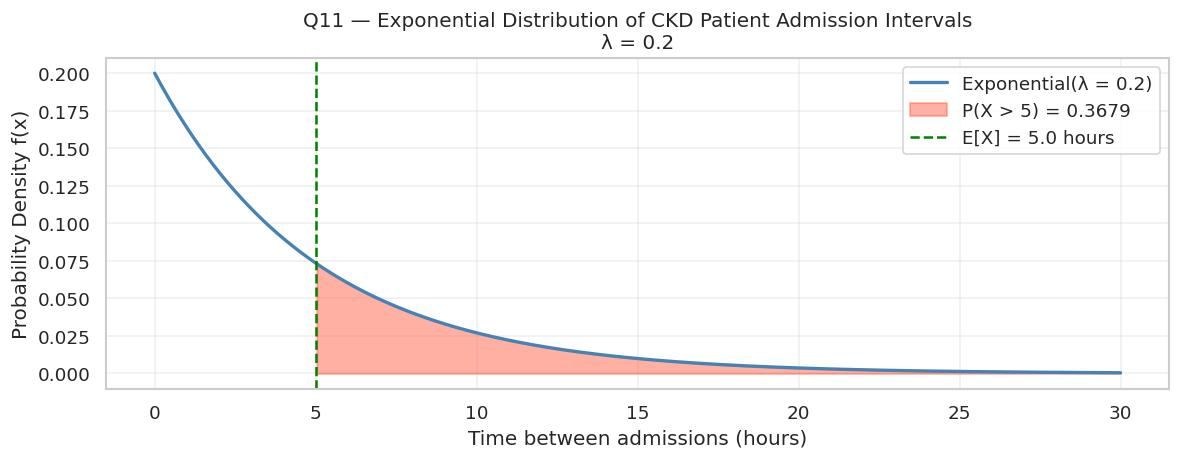


--- Healthcare Interpretation ---
The expected waiting time between consecutive CKD patient admissions is 5.00 hours.
The probability that the next CKD patient arrives after more than 5 hours is 36.79%.
This result can help hospitals estimate patient flow, plan staffing, and allocate nephrology-related resources more effectively.


In [36]:
print('=' * 65)
print('QUESTION 11 — Exponential Distribution (Patient Admission Intervals)')
print('=' * 65)

from scipy.stats import expon

lam = 0.20
scale = 1 / lam

P_gt_5 = expon.sf(
    5,
    scale=scale
)

expected = scale
variance = scale ** 2

print(f'\nParameters: λ = {lam} per hour')
print(f'Scale = 1/λ = {scale:.2f} hours')
print(f'X ~ Exponential(λ = {lam})')

print(
    f'\nPDF: f(x) = λe^(-λx) = {lam}e^(-{lam}x), for x ≥ 0'
)

print(f'P(X > 5) = e^(-λ×5) = e^(-{lam * 5:.2f}) = {P_gt_5:.4f}')
print(f'E[X]     = 1/λ  = {expected:.2f} hours')
print(f'Var[X]   = 1/λ² = {variance:.2f} hours²')

x_e = np.linspace(
    0,
    30,
    400
)

y_e = expon.pdf(
    x_e,
    scale=scale
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    x_e,
    y_e,
    color='steelblue',
    linewidth=2,
    label=f'Exponential(λ = {lam})'
)

x_fill = x_e[x_e >= 5]

ax.fill_between(
    x_fill,
    expon.pdf(x_fill, scale=scale),
    color='tomato',
    alpha=0.5,
    label=f'P(X > 5) = {P_gt_5:.4f}'
)

ax.axvline(
    expected,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'E[X] = {expected:.1f} hours'
)

ax.set_title(
    f'Q11 — Exponential Distribution of CKD Patient Admission Intervals\n'
    f'λ = {lam}'
)

ax.set_xlabel('Time between admissions (hours)')
ax.set_ylabel('Probability Density f(x)')
ax.legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q11_exponential.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'The expected waiting time between consecutive CKD patient admissions '
    f'is {expected:.2f} hours.'
)

print(
    f'The probability that the next CKD patient arrives after more than '
    f'5 hours is {P_gt_5:.2%}.'
)

print(
    'This result can help hospitals estimate patient flow, plan staffing, '
    'and allocate nephrology-related resources more effectively.'
)

---
## Question 12 — Central Limit Theorem

QUESTION 12 — Central Limit Theorem (BloodUrea)

Population: μ = 55 mg/dL, σ = 18 mg/dL
Sample size: n = 36

By CLT: X̄ ~ N(μ, σ²/n) = N(55, 18²/36)

Mean of sampling distribution: μ_X̄ = 55
Standard Error: SE = σ/√n = 18/√36 = 3.0000

Z-score for X̄ = 60: Z = (60 - 55) / 3.0000 = 1.6667
P(X̄ > 60) = P(Z > 1.6667) = 0.0478 = 4.78%


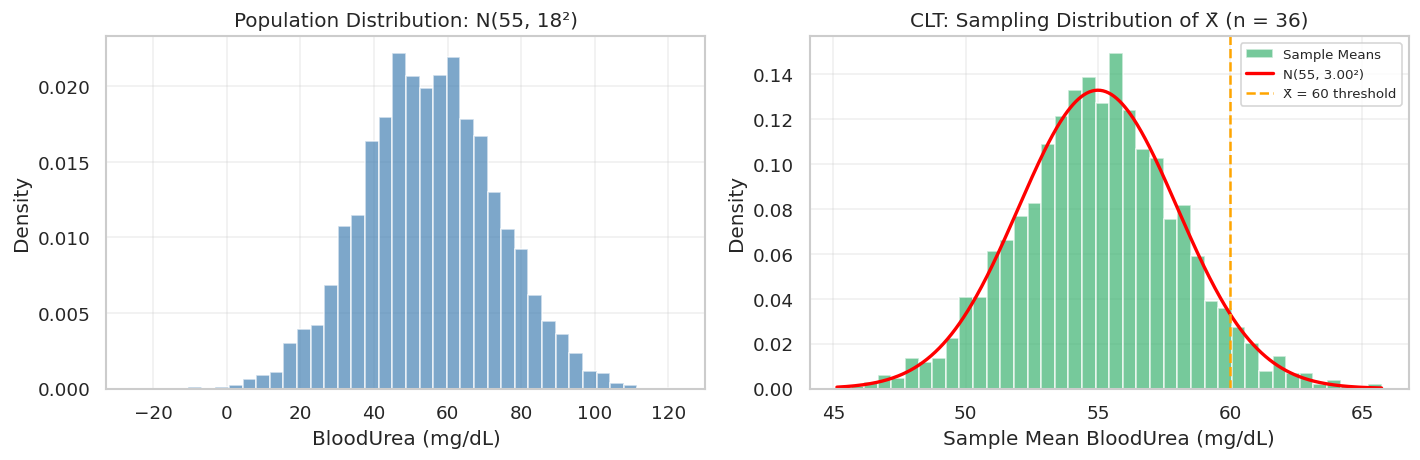


--- Healthcare Interpretation ---
The Central Limit Theorem allows the sampling distribution of the sample mean BloodUrea level to be approximated by a normal distribution.
There is a 4.78% probability that a sample of 36 patients will have a mean BloodUrea level greater than 60 mg/dL.
This helps healthcare researchers evaluate whether observed average BloodUrea levels are unusually high and may indicate kidney dysfunction in the patient group.


In [37]:
print('=' * 65)
print('QUESTION 12 — Central Limit Theorem (BloodUrea)')
print('=' * 65)

from scipy.stats import norm

mu_bu = 55
sigma_bu = 18
n_sample = 36

mean_sampling = mu_bu
SE = sigma_bu / np.sqrt(n_sample)

z_score = (60 - mu_bu) / SE
P_xbar_gt_60 = 1 - norm.cdf(z_score)

print(f'\nPopulation: μ = {mu_bu} mg/dL, σ = {sigma_bu} mg/dL')
print(f'Sample size: n = {n_sample}')

print(
    f'\nBy CLT: X̄ ~ N(μ, σ²/n) = '
    f'N({mu_bu}, {sigma_bu}²/{n_sample})'
)

print(f'\nMean of sampling distribution: μ_X̄ = {mean_sampling}')
print(f'Standard Error: SE = σ/√n = {sigma_bu}/√{n_sample} = {SE:.4f}')

print(
    f'\nZ-score for X̄ = 60: '
    f'Z = (60 - {mu_bu}) / {SE:.4f} = {z_score:.4f}'
)

print(
    f'P(X̄ > 60) = P(Z > {z_score:.4f}) '
    f'= {P_xbar_gt_60:.4f} = {P_xbar_gt_60:.2%}'
)

np.random.seed(42)

sample_means = [
    np.mean(
        np.random.normal(
            mu_bu,
            sigma_bu,
            n_sample
        )
    )
    for _ in range(2000)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pop_vals = np.random.normal(
    mu_bu,
    sigma_bu,
    5000
)

axes[0].hist(
    pop_vals,
    bins=40,
    color='steelblue',
    edgecolor='white',
    density=True,
    alpha=0.7
)

axes[0].set_title(
    f'Population Distribution: N({mu_bu}, {sigma_bu}²)'
)

axes[0].set_xlabel('BloodUrea (mg/dL)')
axes[0].set_ylabel('Density')

axes[1].hist(
    sample_means,
    bins=40,
    color='mediumseagreen',
    edgecolor='white',
    density=True,
    alpha=0.7,
    label='Sample Means'
)

x_norm = np.linspace(
    min(sample_means),
    max(sample_means),
    400
)

axes[1].plot(
    x_norm,
    norm.pdf(
        x_norm,
        mean_sampling,
        SE
    ),
    color='red',
    linewidth=2,
    label=f'N({mu_bu}, {SE:.2f}²)'
)

axes[1].axvline(
    60,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='X̄ = 60 threshold'
)

axes[1].set_title(
    f'CLT: Sampling Distribution of X̄ (n = {n_sample})'
)

axes[1].set_xlabel('Sample Mean BloodUrea (mg/dL)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    '../figures/Q12_CLT.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    'The Central Limit Theorem allows the sampling distribution of the '
    'sample mean BloodUrea level to be approximated by a normal distribution.'
)

print(
    f'There is a {P_xbar_gt_60:.2%} probability that a sample of '
    f'{n_sample} patients will have a mean BloodUrea level greater than '
    '60 mg/dL.'
)

print(
    'This helps healthcare researchers evaluate whether observed average '
    'BloodUrea levels are unusually high and may indicate kidney dysfunction '
    'in the patient group.'
)

---
# SECTION 3 — Confidence Intervals & Hypothesis Testing
## Question 13 — Confidence Interval for SerumCreatinine

QUESTION 13 — 95% Confidence Interval (SerumCreatinine)

Given: n = 64, X̄ = 1.9, s = 0.7
Confidence level = 95%

Degrees of freedom: df = n - 1 = 63
t-critical value = 1.9983
Standard Error: SE = s/√n = 0.0875
Margin of Error: E = t × SE = 0.1749

95% Confidence Interval for population mean SerumCreatinine:
[1.7251, 2.0749] mg/dL
1.9000 ± 0.1749


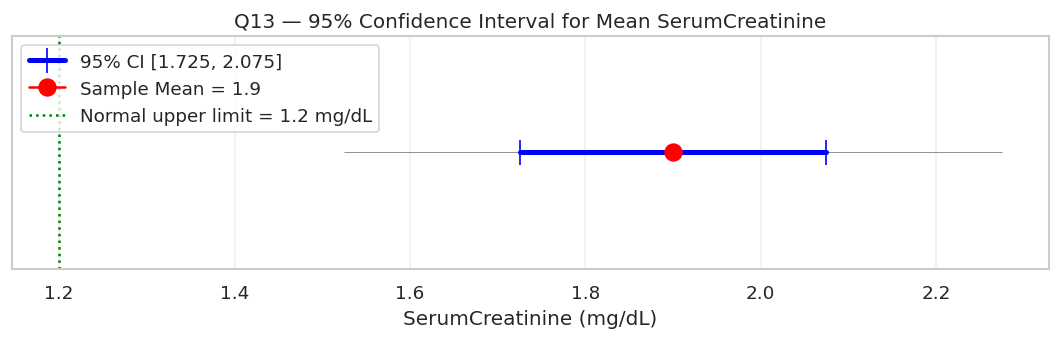


--- Healthcare Interpretation ---
We are 95% confident that the true population mean SerumCreatinine level lies between 1.725 and 2.075 mg/dL.
Since this interval is above the normal upper limit of 1.2 mg/dL, it suggests impaired kidney function among CKD patients.
This confidence interval provides statistical evidence that average SerumCreatinine levels are clinically elevated in the CKD patient group.


In [38]:
print('=' * 65)
print('QUESTION 13 — 95% Confidence Interval (SerumCreatinine)')
print('=' * 65)

n_ci = 64
x_bar_ci = 1.9
s_ci = 0.7
confidence = 0.95
alpha = 1 - confidence

t_crit = stats.t.ppf(
    1 - alpha / 2,
    df=n_ci - 1
)

SE_ci = s_ci / np.sqrt(n_ci)
margin = t_crit * SE_ci

CI_lower = x_bar_ci - margin
CI_upper = x_bar_ci + margin

print(f'\nGiven: n = {n_ci}, X̄ = {x_bar_ci}, s = {s_ci}')
print(f'Confidence level = {confidence:.0%}')

print(f'\nDegrees of freedom: df = n - 1 = {n_ci - 1}')
print(f't-critical value = {t_crit:.4f}')
print(f'Standard Error: SE = s/√n = {SE_ci:.4f}')
print(f'Margin of Error: E = t × SE = {margin:.4f}')

print('\n95% Confidence Interval for population mean SerumCreatinine:')
print(f'[{CI_lower:.4f}, {CI_upper:.4f}] mg/dL')
print(f'{x_bar_ci:.4f} ± {margin:.4f}')

fig, ax = plt.subplots(figsize=(9, 3))

ax.hlines(
    0,
    CI_lower - 0.2,
    CI_upper + 0.2,
    color='gray',
    linewidth=0.5
)

ax.plot(
    [CI_lower, CI_upper],
    [0, 0],
    color='blue',
    marker='|',
    linewidth=3,
    markersize=15,
    label=f'95% CI [{CI_lower:.3f}, {CI_upper:.3f}]'
)

ax.plot(
    x_bar_ci,
    0,
    color='red',
    marker='o',
    markersize=10,
    label=f'Sample Mean = {x_bar_ci}'
)

ax.axvline(
    1.2,
    color='green',
    linestyle=':',
    linewidth=1.5,
    label='Normal upper limit = 1.2 mg/dL'
)

ax.set_xlabel('SerumCreatinine (mg/dL)')
ax.set_title('Q13 — 95% Confidence Interval for Mean SerumCreatinine')
ax.set_yticks([])
ax.legend(loc='upper left')

plt.tight_layout()

plt.savefig(
    '../figures/Q13_CI.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'We are 95% confident that the true population mean SerumCreatinine '
    f'level lies between {CI_lower:.3f} and {CI_upper:.3f} mg/dL.'
)

print(
    'Since this interval is above the normal upper limit of 1.2 mg/dL, '
    'it suggests impaired kidney function among CKD patients.'
)

print(
    'This confidence interval provides statistical evidence that average '
    'SerumCreatinine levels are clinically elevated in the CKD patient group.'
)

---
## Question 14 — One-Sample Z-Test (BloodUrea)

QUESTION 14 — Hypothesis Test: Average BloodUrea > 50 mg/dL

H₀: μ = 50 mg/dL
H₁: μ > 50 mg/dL
Significance level: α = 0.05
Test type: One-tailed right-tailed Z-test

Given: n = 49, X̄ = 57, s = 15
Standard Error: SE = s/√n = 2.1429
Test Statistic: Z = (X̄ - μ₀) / SE = (57 - 50) / 2.1429 = 3.2667
Critical Value: Zα = 1.6449
P-value = 0.000544

--- Decision ---
Z = 3.2667 > Zcritical = 1.6449
Decision: Reject H₀
Conclusion: There is sufficient statistical evidence at the 5% significance level that the average BloodUrea level is greater than 50 mg/dL.


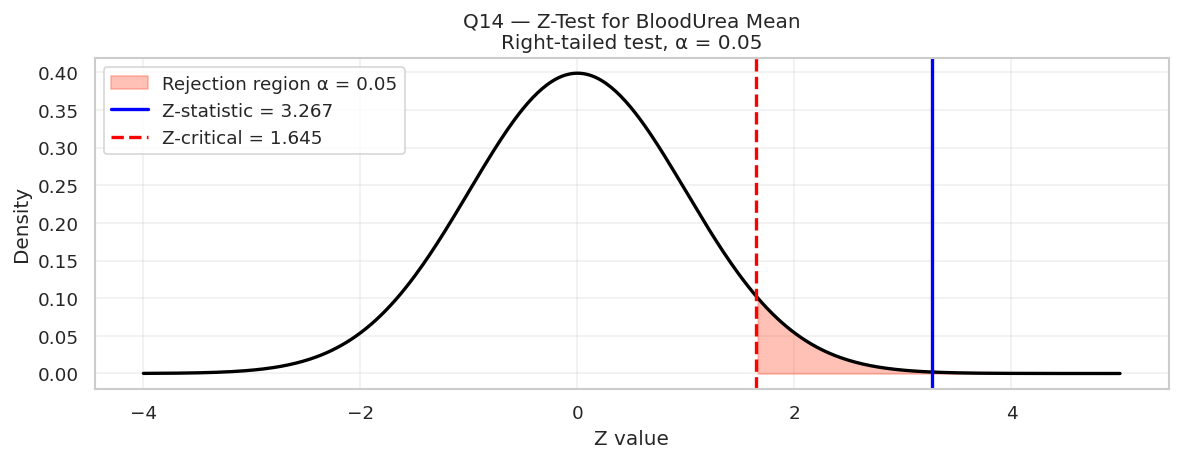


--- Healthcare Interpretation ---
The test result shows that the sample mean BloodUrea level of 57 mg/dL is significantly greater than the claimed mean of 50 mg/dL.
Elevated BloodUrea may indicate reduced kidney filtration ability, which is commonly associated with Chronic Kidney Disease.
This result supports the need for clinical monitoring and further kidney function assessment among patients with high BloodUrea levels.


In [39]:
print('=' * 65)
print('QUESTION 14 — Hypothesis Test: Average BloodUrea > 50 mg/dL')
print('=' * 65)

from scipy.stats import norm

mu_0 = 50
x_bar_bu = 57
s_bu = 15
n_bu = 49
alpha_bu = 0.05

SE_bu = s_bu / np.sqrt(n_bu)

z_stat = (
    x_bar_bu - mu_0
) / SE_bu

z_critical = norm.ppf(
    1 - alpha_bu
)

p_value = 1 - norm.cdf(
    z_stat
)

print(f'\nH₀: μ = {mu_0} mg/dL')
print(f'H₁: μ > {mu_0} mg/dL')
print(f'Significance level: α = {alpha_bu}')
print('Test type: One-tailed right-tailed Z-test')

print(f'\nGiven: n = {n_bu}, X̄ = {x_bar_bu}, s = {s_bu}')
print(f'Standard Error: SE = s/√n = {SE_bu:.4f}')

print(
    f'Test Statistic: Z = (X̄ - μ₀) / SE '
    f'= ({x_bar_bu} - {mu_0}) / {SE_bu:.4f} '
    f'= {z_stat:.4f}'
)

print(f'Critical Value: Zα = {z_critical:.4f}')
print(f'P-value = {p_value:.6f}')

print('\n--- Decision ---')

if z_stat > z_critical:
    print(f'Z = {z_stat:.4f} > Zcritical = {z_critical:.4f}')
    print('Decision: Reject H₀')
    print(
        f'Conclusion: There is sufficient statistical evidence at the '
        f'5% significance level that the average BloodUrea level is '
        f'greater than {mu_0} mg/dL.'
    )
else:
    print(f'Z = {z_stat:.4f} ≤ Zcritical = {z_critical:.4f}')
    print('Decision: Fail to reject H₀')
    print(
        f'Conclusion: There is not sufficient statistical evidence at the '
        f'5% significance level that the average BloodUrea level is '
        f'greater than {mu_0} mg/dL.'
    )

x_z = np.linspace(
    -4,
    5,
    400
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    x_z,
    norm.pdf(x_z),
    color='black',
    linewidth=2
)

x_reject = x_z[x_z >= z_critical]

ax.fill_between(
    x_reject,
    norm.pdf(x_reject),
    color='tomato',
    alpha=0.4,
    label=f'Rejection region α = {alpha_bu}'
)

ax.axvline(
    z_stat,
    color='blue',
    linewidth=2,
    linestyle='-',
    label=f'Z-statistic = {z_stat:.3f}'
)

ax.axvline(
    z_critical,
    color='red',
    linewidth=2,
    linestyle='--',
    label=f'Z-critical = {z_critical:.3f}'
)

ax.set_title(
    'Q14 — Z-Test for BloodUrea Mean\n'
    'Right-tailed test, α = 0.05'
)

ax.set_xlabel('Z value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q14_ztest.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'The test result shows that the sample mean BloodUrea level '
    f'of {x_bar_bu} mg/dL is significantly greater than the claimed '
    f'mean of {mu_0} mg/dL.'
)

print(
    'Elevated BloodUrea may indicate reduced kidney filtration ability, '
    'which is commonly associated with Chronic Kidney Disease.'
)

print(
    'This result supports the need for clinical monitoring and further '
    'kidney function assessment among patients with high BloodUrea levels.'
)

---
## Question 15 — One-Sample T-Test (Hemoglobin)

QUESTION 15 — Hypothesis Test: Hemoglobin < 12.5 g/dL

H₀: μ = 12.5 g/dL
H₁: μ < 12.5 g/dL
Significance level: α = 0.01
Test type: One-tailed left-tailed t-test

Given: n = 64, X̄ = 11.4, s = 1.8
Degrees of freedom: df = 63
Standard Error: SE = s/√n = 0.2250
Test Statistic: t = (X̄ - μ₀) / SE = (11.4 - 12.5) / 0.2250 = -4.8889
Critical Value: tα = -2.3870
P-value = 0.000004

--- Decision ---
t = -4.8889 < tcritical = -2.3870
Decision: Reject H₀
Conclusion: There is sufficient statistical evidence at the 1% significance level that the average Hemoglobin level is less than 12.5 g/dL.


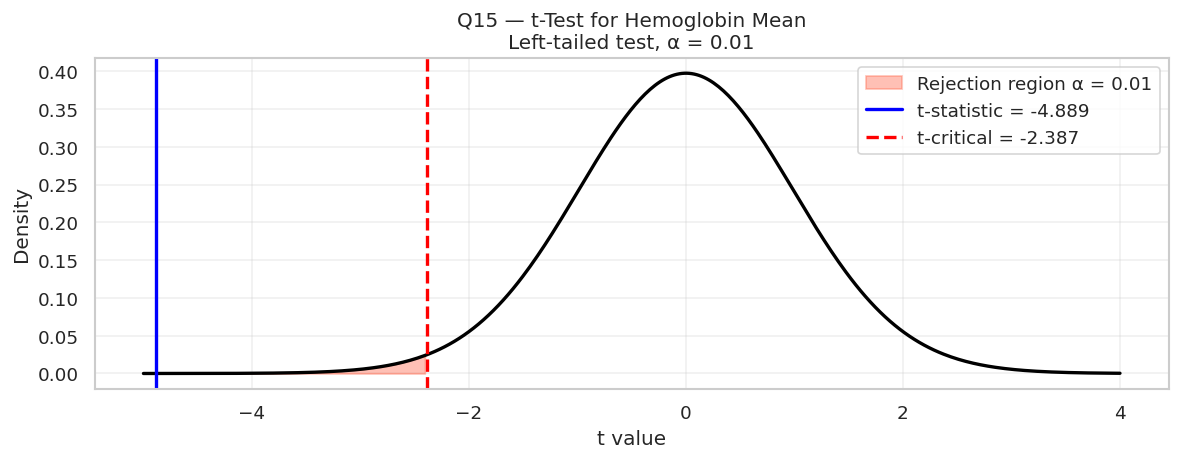


--- Healthcare Interpretation ---
The test result shows that the sample mean Hemoglobin level of 11.4 g/dL is significantly lower than the claimed mean of 12.5 g/dL.
Lower Hemoglobin levels may indicate anemia, which is commonly observed in Chronic Kidney Disease patients.
This occurs because damaged kidneys may produce less erythropoietin, reducing red blood cell production and lowering Hemoglobin levels.


In [40]:
print('=' * 65)
print('QUESTION 15 — Hypothesis Test: Hemoglobin < 12.5 g/dL')
print('=' * 65)

mu_0_hb = 12.5
x_bar_hb = 11.4
s_hb = 1.8
n_hb = 64
alpha_hb = 0.01

SE_hb = s_hb / np.sqrt(n_hb)

t_stat = (
    x_bar_hb - mu_0_hb
) / SE_hb

df_hb = n_hb - 1

t_crit_hb = stats.t.ppf(
    alpha_hb,
    df=df_hb
)

p_value_hb = stats.t.cdf(
    t_stat,
    df=df_hb
)

print(f'\nH₀: μ = {mu_0_hb} g/dL')
print(f'H₁: μ < {mu_0_hb} g/dL')
print(f'Significance level: α = {alpha_hb}')
print('Test type: One-tailed left-tailed t-test')

print(f'\nGiven: n = {n_hb}, X̄ = {x_bar_hb}, s = {s_hb}')
print(f'Degrees of freedom: df = {df_hb}')
print(f'Standard Error: SE = s/√n = {SE_hb:.4f}')

print(
    f'Test Statistic: t = (X̄ - μ₀) / SE '
    f'= ({x_bar_hb} - {mu_0_hb}) / {SE_hb:.4f} '
    f'= {t_stat:.4f}'
)

print(f'Critical Value: tα = {t_crit_hb:.4f}')
print(f'P-value = {p_value_hb:.6f}')

print('\n--- Decision ---')

if t_stat < t_crit_hb:
    print(f't = {t_stat:.4f} < tcritical = {t_crit_hb:.4f}')
    print('Decision: Reject H₀')
    print(
        'Conclusion: There is sufficient statistical evidence at the '
        '1% significance level that the average Hemoglobin level is '
        f'less than {mu_0_hb} g/dL.'
    )
else:
    print(f't = {t_stat:.4f} ≥ tcritical = {t_crit_hb:.4f}')
    print('Decision: Fail to reject H₀')
    print(
        'Conclusion: There is not sufficient statistical evidence at the '
        '1% significance level that the average Hemoglobin level is '
        f'less than {mu_0_hb} g/dL.'
    )

x_t = np.linspace(
    -5,
    4,
    400
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    x_t,
    stats.t.pdf(x_t, df=df_hb),
    color='black',
    linewidth=2
)

x_reject_left = x_t[x_t <= t_crit_hb]

ax.fill_between(
    x_reject_left,
    stats.t.pdf(x_reject_left, df=df_hb),
    color='tomato',
    alpha=0.4,
    label=f'Rejection region α = {alpha_hb}'
)

ax.axvline(
    t_stat,
    color='blue',
    linewidth=2,
    label=f't-statistic = {t_stat:.3f}'
)

ax.axvline(
    t_crit_hb,
    color='red',
    linewidth=2,
    linestyle='--',
    label=f't-critical = {t_crit_hb:.3f}'
)

ax.set_title(
    f'Q15 — t-Test for Hemoglobin Mean\n'
    f'Left-tailed test, α = {alpha_hb}'
)

ax.set_xlabel('t value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q15_ttest.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'The test result shows that the sample mean Hemoglobin level '
    f'of {x_bar_hb} g/dL is significantly lower than the claimed '
    f'mean of {mu_0_hb} g/dL.'
)

print(
    'Lower Hemoglobin levels may indicate anemia, which is commonly '
    'observed in Chronic Kidney Disease patients.'
)

print(
    'This occurs because damaged kidneys may produce less erythropoietin, '
    'reducing red blood cell production and lowering Hemoglobin levels.'
)

---
# SECTION 4 — Correlation, Regression & Healthcare Investigation
## Question 16 — Correlation Analysis

In [41]:
print('=' * 65)
print('QUESTION 16 — Correlation Analysis')
print('=' * 65)

pairs = [
    ('SerumCreatinine', 'BloodUrea'),
    ('BloodPressure', 'SerumCreatinine'),
    ('Hemoglobin', 'CKD'),
    ('Potassium', 'Sodium')
]

df_q16 = df_raw.copy()

df_q16['CKD'] = (
    df_q16['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

needed_cols = [
    'SerumCreatinine',
    'BloodUrea',
    'BloodPressure',
    'Hemoglobin',
    'CKD',
    'Potassium',
    'Sodium'
]

for col in needed_cols:
    df_q16[col] = pd.to_numeric(
        df_q16[col],
        errors='coerce'
    )

corr_results = []

for v1, v2 in pairs:

    valid = df_q16[[v1, v2]].dropna()

    r, p = stats.pearsonr(
        valid[v1],
        valid[v2]
    )

    if abs(r) >= 0.7:
        strength = 'Strong'
    elif abs(r) >= 0.3:
        strength = 'Moderate'
    else:
        strength = 'Weak'

    if r > 0:
        direction = 'Positive'
    elif r < 0:
        direction = 'Negative'
    else:
        direction = 'No direction'

    if p < 0.001:
        significance = '***'
    elif p < 0.01:
        significance = '**'
    elif p < 0.05:
        significance = '*'
    else:
        significance = 'NS'

    corr_results.append({
        'Pair': f'{v1} vs {v2}',
        'Valid N': len(valid),
        'r': round(r, 4),
        'p-value': round(p, 6),
        'Significance': significance,
        'Strength': strength,
        'Direction': direction
    })

corr_df = pd.DataFrame(corr_results)

print('\nPearson Correlation Results:')
display(corr_df)

print('\nSignificance Key:')
print('*** p < 0.001, ** p < 0.01, * p < 0.05, NS = not significant')

print('\n--- Healthcare Interpretation ---')

for _, row in corr_df.iterrows():

    pair = row['Pair']

    print(
        f'{pair}: r = {row["r"]}, '
        f'{row["Strength"]} {row["Direction"]} correlation.'
    )

    if pair == 'SerumCreatinine vs BloodUrea':
        print(
            'Both are kidney function markers; a positive correlation suggests '
            'that creatinine and urea tend to increase together when kidney '
            'filtration worsens.'
        )

    elif pair == 'BloodPressure vs SerumCreatinine':
        print(
            'A positive relationship may suggest that higher blood pressure is '
            'associated with reduced kidney function.'
        )

    elif pair == 'Hemoglobin vs CKD':
        print(
            'A negative correlation indicates that CKD patients tend to have '
            'lower Hemoglobin levels, which is consistent with anemia in CKD.'
        )

    elif pair == 'Potassium vs Sodium':
        print(
            'This relationship reflects electrolyte balance, which can be '
            'affected when kidney regulation is impaired.'
        )

    print()

QUESTION 16 — Correlation Analysis

Pearson Correlation Results:


,Pair,Valid N,r,p-value,Significance,Strength,Direction
0,SerumCreatinine vs BloodUrea,380,0.5864,0.000000,***,Moderate,Positive
1,BloodPressure vs SerumCreatinine,373,0.1462,0.004658,**,Weak,Positive
2,Hemoglobin vs CKD,348,-0.7689,0.000000,***,Strong,Negative
3,Potassium vs Sodium,312,0.0979,0.084306,NS,Weak,Positive



Significance Key:
*** p < 0.001, ** p < 0.01, * p < 0.05, NS = not significant

--- Healthcare Interpretation ---
SerumCreatinine vs BloodUrea: r = 0.5864, Moderate Positive correlation.
Both are kidney function markers; a positive correlation suggests that creatinine and urea tend to increase together when kidney filtration worsens.

BloodPressure vs SerumCreatinine: r = 0.1462, Weak Positive correlation.
A positive relationship may suggest that higher blood pressure is associated with reduced kidney function.

Hemoglobin vs CKD: r = -0.7689, Strong Negative correlation.
A negative correlation indicates that CKD patients tend to have lower Hemoglobin levels, which is consistent with anemia in CKD.

Potassium vs Sodium: r = 0.0979, Weak Positive correlation.
This relationship reflects electrolyte balance, which can be affected when kidney regulation is impaired.



---
## Question 17 — Linear Regression

QUESTION 17 — Linear Regression: BloodPressure → SerumCreatinine

Regression Equation: SerumCreatinine = -1.5727 + 0.0610 × BloodPressure
Slope β₁      = 0.060984
Intercept β₀  = -1.5727
R² value      = 0.0214 (2.14% variance explained)
Pearson r     = 0.1462
p-value       = 0.004658

Sample Predictions:
BloodPressure = 70 mmHg → Predicted SerumCreatinine = 2.6962 mg/dL
BloodPressure = 80 mmHg → Predicted SerumCreatinine = 3.3060 mg/dL
BloodPressure = 90 mmHg → Predicted SerumCreatinine = 3.9158 mg/dL
BloodPressure = 100 mmHg → Predicted SerumCreatinine = 4.5257 mg/dL


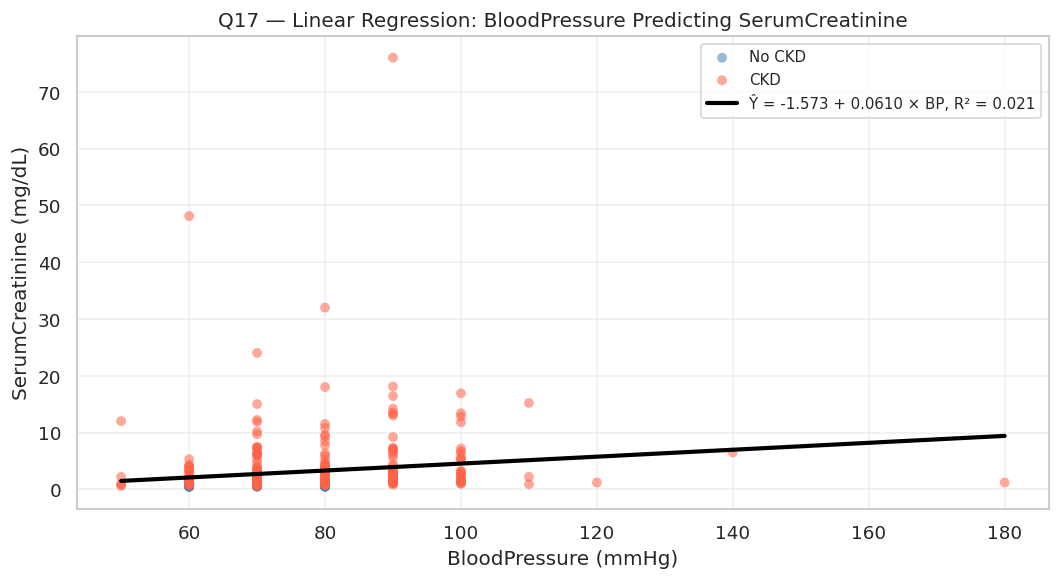


--- Healthcare Interpretation ---
The slope value of 0.0610 means that for every 1 mmHg increase in BloodPressure, the predicted SerumCreatinine level changes by 0.0610 mg/dL.
The R² value of 0.0214 indicates that BloodPressure explains about 2.14% of the variation in SerumCreatinine.
A positive relationship suggests that higher blood pressure may be associated with poorer kidney function, although BloodPressure alone has limited predictive power.
This supports the healthcare importance of blood pressure control in CKD prevention and management.


In [42]:
print('=' * 65)
print('QUESTION 17 — Linear Regression: BloodPressure → SerumCreatinine')
print('=' * 65)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from matplotlib.patches import Patch

df_q17 = df_raw.copy()

df_q17['BloodPressure'] = pd.to_numeric(
    df_q17['BloodPressure'],
    errors='coerce'
)

df_q17['SerumCreatinine'] = pd.to_numeric(
    df_q17['SerumCreatinine'],
    errors='coerce'
)

df_q17['CKD'] = (
    df_q17['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_q17['CKD'] = pd.to_numeric(
    df_q17['CKD'],
    errors='coerce'
)

reg_data = df_q17[
    ['BloodPressure', 'SerumCreatinine', 'CKD']
].dropna(
    subset=['BloodPressure', 'SerumCreatinine']
)

X_reg = reg_data['BloodPressure'].values.reshape(-1, 1)
y_reg = reg_data['SerumCreatinine'].values

model = LinearRegression()
model.fit(X_reg, y_reg)

y_pred = model.predict(X_reg)

slope = model.coef_[0]
intercept = model.intercept_

r_sq = r2_score(
    y_reg,
    y_pred
)

r_val, p_reg = stats.pearsonr(
    reg_data['BloodPressure'],
    reg_data['SerumCreatinine']
)

print(
    f'\nRegression Equation: SerumCreatinine = '
    f'{intercept:.4f} + {slope:.4f} × BloodPressure'
)

print(f'Slope β₁      = {slope:.6f}')
print(f'Intercept β₀  = {intercept:.4f}')
print(f'R² value      = {r_sq:.4f} ({r_sq * 100:.2f}% variance explained)')
print(f'Pearson r     = {r_val:.4f}')
print(f'p-value       = {p_reg:.6f}')

print('\nSample Predictions:')

for bp_val in [70, 80, 90, 100]:

    pred = intercept + slope * bp_val

    print(
        f'BloodPressure = {bp_val} mmHg → '
        f'Predicted SerumCreatinine = {pred:.4f} mg/dL'
    )

x_line = np.linspace(
    X_reg.min(),
    X_reg.max(),
    100
)

y_line = intercept + slope * x_line

fig, ax = plt.subplots(figsize=(9, 5))

non_ckd_points = reg_data[reg_data['CKD'] == 0]
ckd_points = reg_data[reg_data['CKD'] == 1]
unknown_points = reg_data[reg_data['CKD'].isna()]

ax.scatter(
    non_ckd_points['BloodPressure'],
    non_ckd_points['SerumCreatinine'],
    color='steelblue',
    alpha=0.55,
    s=35,
    edgecolors='none',
    label='No CKD'
)

ax.scatter(
    ckd_points['BloodPressure'],
    ckd_points['SerumCreatinine'],
    color='tomato',
    alpha=0.55,
    s=35,
    edgecolors='none',
    label='CKD'
)

if len(unknown_points) > 0:
    ax.scatter(
        unknown_points['BloodPressure'],
        unknown_points['SerumCreatinine'],
        color='gray',
        alpha=0.45,
        s=35,
        edgecolors='none',
        label='Unknown CKD'
    )

line_plot, = ax.plot(
    x_line,
    y_line,
    color='black',
    linewidth=2.5,
    label=f'Ŷ = {intercept:.3f} + {slope:.4f} × BP, R² = {r_sq:.3f}'
)

ax.set_xlabel('BloodPressure (mmHg)')
ax.set_ylabel('SerumCreatinine (mg/dL)')
ax.set_title('Q17 — Linear Regression: BloodPressure Predicting SerumCreatinine')
ax.legend(fontsize=9)

plt.tight_layout()

plt.savefig(
    '../figures/Q17_regression.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'The slope value of {slope:.4f} means that for every 1 mmHg increase '
    f'in BloodPressure, the predicted SerumCreatinine level changes by '
    f'{slope:.4f} mg/dL.'
)

print(
    f'The R² value of {r_sq:.4f} indicates that BloodPressure explains '
    f'about {r_sq * 100:.2f}% of the variation in SerumCreatinine.'
)

print(
    'A positive relationship suggests that higher blood pressure may be '
    'associated with poorer kidney function, although BloodPressure alone '
    'has limited predictive power.'
)

print(
    'This supports the healthcare importance of blood pressure control '
    'in CKD prevention and management.'
)

---
## Question 18 — Correlation Heatmap & Pairplot

QUESTION 18 — Correlation Heatmap & Scatter Plot Matrix


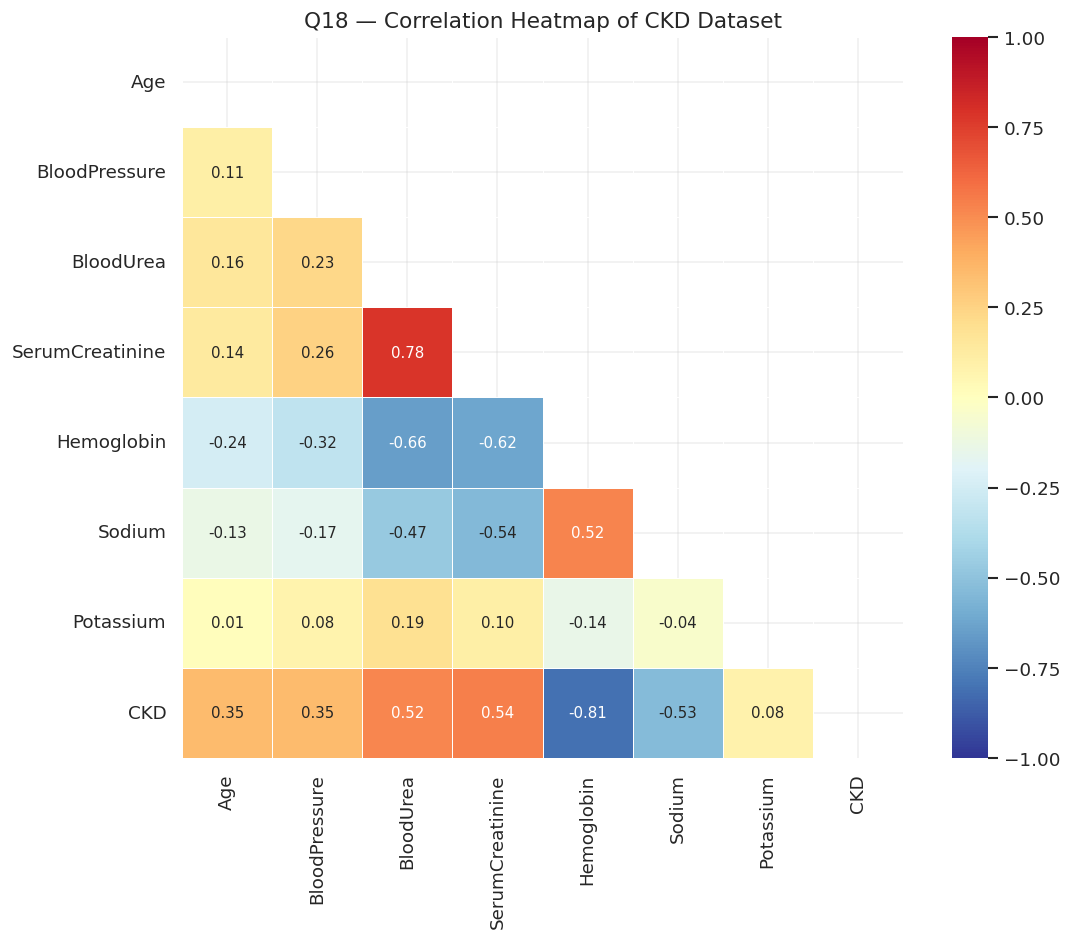

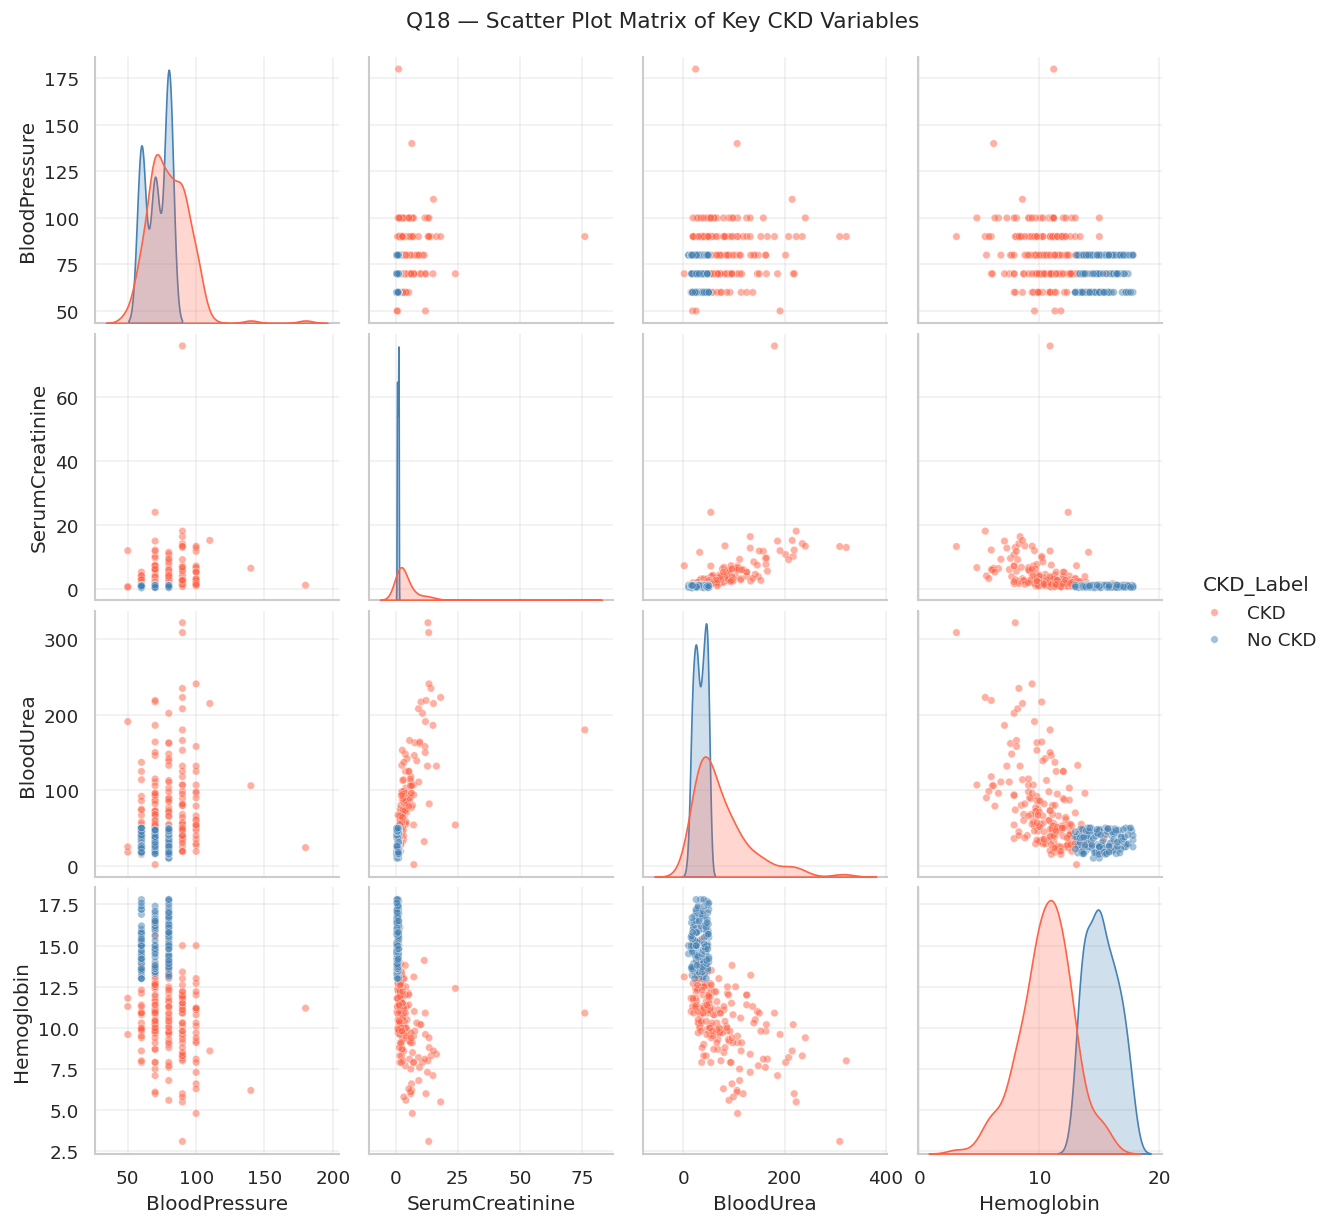


--- Healthcare Interpretation ---
The correlation heatmap shows the strength and direction of relationships among important CKD-related variables.
SerumCreatinine and BloodUrea are expected to show a positive relationship because both are kidney function markers that rise when filtration worsens.
Hemoglobin is expected to show a negative relationship with CKD because CKD patients often experience anemia.
BloodPressure may show a positive relationship with CKD-related markers, supporting the role of hypertension as a risk factor for kidney disease.
The scatter plot matrix helps visually compare CKD and non-CKD patients and identify major risk factor patterns in the dataset.


In [43]:
print('=' * 65)
print('QUESTION 18 — Correlation Heatmap & Scatter Plot Matrix')
print('=' * 65)

df_q18 = df_raw.copy()

df_q18['CKD'] = (
    df_q18['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

viz_cols = [
    'Age',
    'BloodPressure',
    'BloodUrea',
    'SerumCreatinine',
    'Hemoglobin',
    'Sodium',
    'Potassium',
    'CKD'
]

for col in viz_cols:
    df_q18[col] = pd.to_numeric(
        df_q18[col],
        errors='coerce'
    )

df_viz = df_q18[viz_cols].dropna()

corr_matrix = df_viz.corr()

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(
    np.ones_like(
        corr_matrix,
        dtype=bool
    )
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    ax=ax,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={'size': 9}
)

ax.set_title(
    'Q18 — Correlation Heatmap of CKD Dataset',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    '../figures/Q18_heatmap.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

pair_cols = [
    'BloodPressure',
    'SerumCreatinine',
    'BloodUrea',
    'Hemoglobin',
    'CKD'
]

df_pair = df_q18[pair_cols].dropna()

df_pair['CKD_Label'] = df_pair['CKD'].map({
    1: 'CKD',
    0: 'No CKD'
})

pairplot_fig = sns.pairplot(
    df_pair.drop('CKD', axis=1),
    hue='CKD_Label',
    palette={
        'CKD': 'tomato',
        'No CKD': 'steelblue'
    },
    plot_kws={
        'alpha': 0.5,
        's': 20
    },
    diag_kind='kde'
)

pairplot_fig.figure.suptitle(
    'Q18 — Scatter Plot Matrix of Key CKD Variables',
    y=1.02,
    fontsize=13
)

plt.savefig(
    '../figures/Q18_pairplot.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    'The correlation heatmap shows the strength and direction of relationships '
    'among important CKD-related variables.'
)

print(
    'SerumCreatinine and BloodUrea are expected to show a positive relationship '
    'because both are kidney function markers that rise when filtration worsens.'
)

print(
    'Hemoglobin is expected to show a negative relationship with CKD because '
    'CKD patients often experience anemia.'
)

print(
    'BloodPressure may show a positive relationship with CKD-related markers, '
    'supporting the role of hypertension as a risk factor for kidney disease.'
)

print(
    'The scatter plot matrix helps visually compare CKD and non-CKD patients '
    'and identify major risk factor patterns in the dataset.'
)

---
## Question 19 — Healthcare Investigation: CKD vs Non-CKD Statistical Test

QUESTION 19 — CKD vs Non-CKD: Independent Samples t-Test

CKD patients     : 250
Non-CKD patients : 150

Independent Samples t-Test Results:


,Variable,CKD Mean,Non-CKD Mean,t-statistic,p-value,Significant (p<0.05)
0,SerumCreatinine,4.415,0.869,7.8621,0.0,YES
1,BloodUrea,72.389,32.799,10.0907,0.0,YES
2,Hemoglobin,10.648,15.188,-24.3565,0.0,YES
3,BloodPressure,79.625,71.351,6.8469,0.0,YES


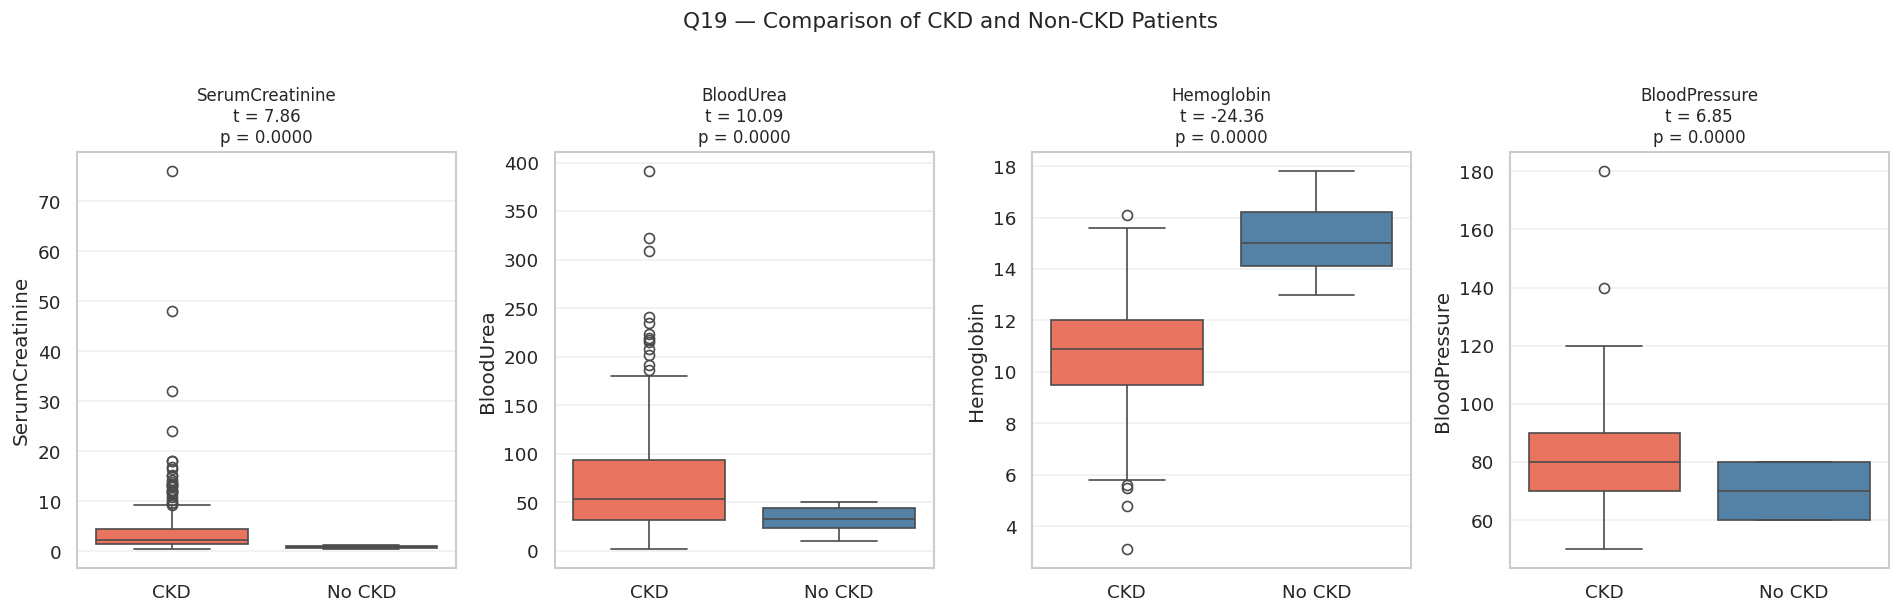


--- Healthcare Interpretation ---
SerumCreatinine: CKD mean is higher by 3.546. Statistically significant: YES.
BloodUrea: CKD mean is higher by 39.590. Statistically significant: YES.
Hemoglobin: CKD mean is lower by 4.540. Statistically significant: YES.
BloodPressure: CKD mean is higher by 8.274. Statistically significant: YES.

The independent samples t-test evaluates whether CKD and non-CKD patients differ significantly in important clinical measurements.
Significant differences suggest that the variable may be useful for distinguishing CKD patients from healthy individuals.


In [44]:
print('=' * 65)
print('QUESTION 19 — CKD vs Non-CKD: Independent Samples t-Test')
print('=' * 65)

df_q19 = df_raw.copy()

df_q19['CKD'] = (
    df_q19['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

test_vars = [
    'SerumCreatinine',
    'BloodUrea',
    'Hemoglobin',
    'BloodPressure',
    'CKD'
]

for col in test_vars:
    df_q19[col] = pd.to_numeric(
        df_q19[col],
        errors='coerce'
    )

df_inv = df_q19.dropna(subset=['CKD'])

ckd_g = df_inv[df_inv['CKD'] == 1]
non_ckd_g = df_inv[df_inv['CKD'] == 0]

print(f'\nCKD patients     : {len(ckd_g)}')
print(f'Non-CKD patients : {len(non_ckd_g)}')

inv_vars = [
    'SerumCreatinine',
    'BloodUrea',
    'Hemoglobin',
    'BloodPressure'
]

results = []

for var in inv_vars:

    g1 = ckd_g[var].dropna()
    g2 = non_ckd_g[var].dropna()

    t_stat, p_value = stats.ttest_ind(
        g1,
        g2,
        equal_var=False
    )

    results.append({
        'Variable': var,
        'CKD Mean': round(g1.mean(), 3),
        'Non-CKD Mean': round(g2.mean(), 3),
        't-statistic': round(t_stat, 4),
        'p-value': round(p_value, 6),
        'Significant (p<0.05)': (
            'YES' if p_value < 0.05 else 'NO'
        )
    })

res_df = pd.DataFrame(results)

print('\nIndependent Samples t-Test Results:')
display(res_df)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 5)
)

for i, var in enumerate(inv_vars):

    data_plot = df_inv[
        ['CKD', var]
    ].dropna()

    data_plot['Group'] = data_plot['CKD'].map({
        1: 'CKD',
        0: 'No CKD'
    })

    sns.boxplot(
        x='Group',
        y=var,
        data=data_plot,
        hue='Group',
        palette={
            'CKD': 'tomato',
            'No CKD': 'steelblue'
        },
        legend=False,
        ax=axes[i]
    )

    row = res_df[
        res_df['Variable'] == var
    ].iloc[0]

    axes[i].set_title(
        f'{var}\n'
        f't = {row["t-statistic"]:.2f}\n'
        f'p = {row["p-value"]:.4f}',
        fontsize=10
    )

    axes[i].set_xlabel('')

fig.suptitle(
    'Q19 — Comparison of CKD and Non-CKD Patients',
    fontsize=13,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    '../figures/Q19_comparison.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

for _, row in res_df.iterrows():

    diff = (
        row['CKD Mean']
        - row['Non-CKD Mean']
    )

    direction = (
        'higher'
        if diff > 0
        else 'lower'
    )

    print(
        f'{row["Variable"]}: '
        f'CKD mean is {direction} by '
        f'{abs(diff):.3f}. '
        f'Statistically significant: '
        f'{row["Significant (p<0.05)"]}.'
    )

print()

print(
    'The independent samples t-test evaluates whether CKD and non-CKD '
    'patients differ significantly in important clinical measurements.'
)

print(
    'Significant differences suggest that the variable may be useful for '
    'distinguishing CKD patients from healthy individuals.'
)

---
## Question 20 — Evidence-Based Conclusion

In [46]:
print('=' * 65)
print('QUESTION 20 — Complete Evidence-Based CKD Conclusion')
print('=' * 65)

conclusion = """
EVIDENCE-BASED CONCLUSION: CKD STATISTICAL ANALYSIS

1. Descriptive Analysis
CKD patients showed higher average SerumCreatinine and BloodUrea levels than non-CKD patients. These findings indicate reduced kidney filtration ability. CKD patients also showed lower Hemoglobin levels, suggesting anemia, and higher BloodPressure, supporting the relationship between hypertension and kidney disease.

2. Probability and Bayes Theorem
Conditional probability and Bayes theorem showed that patients with elevated SerumCreatinine have a much higher probability of having CKD. This supports SerumCreatinine as an important clinical screening indicator.

3. Distribution Analysis
The binomial distribution helped estimate CKD occurrence in a fixed group of patients. The normal distribution model was used to classify SerumCreatinine levels into normal, moderate-risk, and high-risk ranges. The uniform distribution model described patient age probability, while the exponential distribution modeled waiting time between CKD patient admissions.

4. Central Limit Theorem
The Central Limit Theorem showed that the sampling distribution of mean BloodUrea can be approximated by a normal distribution for a sufficiently large sample. This helps healthcare researchers make reliable conclusions about population-level kidney function using sample data.

5. Confidence Interval
The 95% confidence interval for mean SerumCreatinine was above the normal reference limit. This provides statistical evidence that CKD patients have clinically elevated SerumCreatinine levels.

6. Hypothesis Testing
The BloodUrea hypothesis test showed that the average BloodUrea level was significantly greater than 50 mg/dL. The Hemoglobin hypothesis test showed that the average Hemoglobin level was significantly less than 12.5 g/dL. These results support the presence of kidney dysfunction and anemia among CKD patients.

7. Correlation and Regression
Correlation analysis showed relationships among important CKD-related variables. SerumCreatinine and BloodUrea were positively related, while Hemoglobin was negatively associated with CKD status. Linear regression showed that BloodPressure has a positive relationship with SerumCreatinine, although BloodPressure alone may not fully explain kidney function variation.

8. Major CKD Risk Factors Identified
The major risk factors and indicators observed in this analysis were elevated SerumCreatinine, elevated BloodUrea, low Hemoglobin, high BloodPressure, electrolyte imbalance, hypertension, and diabetes mellitus.

9. Preventive Recommendations
Patients with hypertension or diabetes should regularly monitor SerumCreatinine, BloodUrea, BloodPressure, and Hemoglobin. Early screening, blood pressure control, diabetes management, anemia monitoring, and lifestyle modification can help reduce CKD progression risk.

10. Final Statistical Conclusion
Overall, the statistical analyses consistently show clear differences between CKD and non-CKD patients. SerumCreatinine, BloodUrea, Hemoglobin, and BloodPressure are important variables for understanding CKD risk. Combining descriptive statistics, probability, Bayes theorem, distributions, confidence intervals, hypothesis testing, correlation, regression, and visualization provides strong evidence that CKD occurrence can be statistically investigated and meaningfully predicted using healthcare data.
"""

print(conclusion)

QUESTION 20 — Complete Evidence-Based CKD Conclusion

EVIDENCE-BASED CONCLUSION: CKD STATISTICAL ANALYSIS

1. Descriptive Analysis
CKD patients showed higher average SerumCreatinine and BloodUrea levels than non-CKD patients. These findings indicate reduced kidney filtration ability. CKD patients also showed lower Hemoglobin levels, suggesting anemia, and higher BloodPressure, supporting the relationship between hypertension and kidney disease.

2. Probability and Bayes Theorem
Conditional probability and Bayes theorem showed that patients with elevated SerumCreatinine have a much higher probability of having CKD. This supports SerumCreatinine as an important clinical screening indicator.

3. Distribution Analysis
The binomial distribution helped estimate CKD occurrence in a fixed group of patients. The normal distribution model was used to classify SerumCreatinine levels into normal, moderate-risk, and high-risk ranges. The uniform distribution model described patient age probability,